# SPS MBB Dipole -- Comprehensive Analysis (26 GeV)

**Measurement session:** 
**Segments:** body (main body), fringe
**Magnet:** MBB (normal dipole, m=1)
**Rotation:** ~176 RPM (~2.93 Hz)


---
## 1. Configuration & Imports

In [1]:
# === CONFIGURATION ===
SEGMENT_CONFIGS = [
    {"name": "body", "kn_path": "MBB/2026-03-06_max_speed_NMR/20260306_153553_SPS_MBB/Kn_values_Seg_body.txt", "merge_mode": "abs_upto_m_cmp_above", "is_fringe": False},
    {"name": "fringe", "kn_path": "MBB/2026-03-06_max_speed_NMR/20260306_153553_SPS_MBB/Kn_values_Seg_fringe.txt", "merge_mode": "abs_upto_m_cmp_above", "is_fringe": True},
]
SEGMENTS = [s["name"] for s in SEGMENT_CONFIGS]
SEG_DISPLAY = {s["name"]: (s["name"] + " [fringe]" if s["is_fringe"] else s["name"] + " [main body]") for s in SEGMENT_CONFIGS}

SESSION = "MBB/2026-03-06_max_speed_NMR/20260306_153553_SPS_MBB"
MEAS_SUBDIR = "20260306_153614_MBB"
KN_PATHS = {"body": "MBB/2026-03-06_max_speed_NMR/20260306_153553_SPS_MBB/Kn_values_Seg_body.txt", "fringe": "MBB/2026-03-06_max_speed_NMR/20260306_153553_SPS_MBB/Kn_values_Seg_fringe.txt"}

MAGNET_ORDER = 1
R_REF = 0.02
L_COIL = 0.47
SAMPLES_PER_TURN = 1024

OPTIONS = ('dri', 'rot', 'cel', 'fed')
MIN_B1_T = 0.0001
PLATEAU_I_RANGE_MAX = 2.5
N_BLOCKS = 10

N_LAST_TURNS_INJ = 18
N_LAST_TURNS_HIGH = None

N_SIGMA_CLIP = 5.0
MIN_INJECTION_TURNS = 5

print("SPS MBB Dipole -- 26 GeV MD1, ~176 RPM")
print("=" * 60)
print(f"  Segments      : {SEGMENTS}")
print(f"  Magnet order  : {MAGNET_ORDER}")
print(f"  R_ref         : {R_REF} m")
print(f"  Samples/turn  : {SAMPLES_PER_TURN}")
print(f"  Options       : {OPTIONS}")


SPS MBB Dipole -- 26 GeV MD1, ~176 RPM
  Segments      : ['body', 'fringe']
  Magnet order  : 1
  R_ref         : 0.02 m
  Samples/turn  : 1024
  Options       : ('dri', 'rot', 'cel', 'fed')


In [2]:
import sys
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import curve_fit

%matplotlib widget
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists():
        break
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    process_kn_pipeline,
    build_harmonic_rows,
    diagnose_cel_fed,
    mad_sigma_clip,
    eddy_model,
    fit_eddy_per_run,
    plateau_summary,
    compute_block_averaged_range,
    detect_plateau_turns,
    classify_current,
    find_contiguous_groups,
    diagnose_fdi_transitions,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

SESSION_DIR = REPO_ROOT / "measurements" / SESSION
RUN_DIR = SESSION_DIR / MEAS_SUBDIR

KN = {}
for _seg_name, _kn_rel in KN_PATHS.items():
    _kp = REPO_ROOT / "measurements" / _kn_rel
    assert _kp.exists(), f"Kn file not found: {_kp}"
    KN[_seg_name] = load_segment_kn_txt(str(_kp))

print(f"Repo root : {REPO_ROOT}")
print(f"Kn loaded : {list(KN.keys())}")
print("Imports ready.")

Repo root : C:\Users\albellel\python-projects\rotating-coil-analyzer
Kn loaded : ['body', 'fringe']
Imports ready.


---
## 2. Kn Calibration

In [3]:
for seg_name, kn_seg in KN.items():
    H = len(kn_seg.orders)
    print(f"\n{seg_name}: {H} harmonics")
    print(f"  Orders: {list(kn_seg.orders)}")
    kn_abs_n1 = abs(kn_seg.kn_abs[0])
    kn_cmp_n1 = abs(kn_seg.kn_cmp[0])
    ratio = kn_abs_n1 / max(kn_cmp_n1, 1e-30)
    print(f"  |Kn_abs(n=1)| = {kn_abs_n1:.6e}")
    print(f"  |Kn_cmp(n=1)| = {kn_cmp_n1:.6e}")
    print(f"  Abs/Cmp ratio (n=1): {ratio:.0f}x")

# Use first segment's Kn for harmonic count
_first_seg = SEGMENTS[0]
H = len(KN[_first_seg].orders)
Ns = SAMPLES_PER_TURN
m = MAGNET_ORDER
print(f"\nH={H}, Ns={Ns}, m={m}")


body: 15 harmonics
  Orders: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
  |Kn_abs(n=1)| = 1.154977e-01
  |Kn_cmp(n=1)| = 9.111878e-05
  Abs/Cmp ratio (n=1): 1268x

fringe: 15 harmonics
  Orders: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
  |Kn_abs(n=1)| = 1.155306e-01
  |Kn_cmp(n=1)| = 5.179355e-05
  Abs/Cmp ratio (n=1): 2231x

H=15, Ns=1024, m=1


---
## 3. Data Loading & Channel Detection

Load raw measurement data for all segments.

In [4]:
FILE_PAT = re.compile(
    r"Run_(\d+)_I_([\d.]+)A_(body|fringe)_raw_measurement_data\.txt$"
)

data = {}
for seg in SEGMENTS:
    seg_files = [
        f for f in sorted(RUN_DIR.iterdir())
        if FILE_PAT.search(f.name) and FILE_PAT.search(f.name).group(3) == seg
    ]
    assert seg_files, f"No {seg} raw files in {RUN_DIR}"
    raw_file = seg_files[0]

    raw = np.loadtxt(raw_file)
    n_turns = raw.shape[0] // Ns
    n_keep = n_turns * Ns
    ncols = raw.shape[1]

    t_all = raw[:n_keep, 0].reshape(n_turns, Ns)
    flux_col1 = raw[:n_keep, 1].reshape(n_turns, Ns)
    flux_col2 = raw[:n_keep, 2].reshape(n_turns, Ns)
    I_all = raw[:n_keep, 3].reshape(n_turns, Ns)

    # Auto-detect channel swap
    I_mean_quick = I_all.mean(axis=1)
    best_turn = np.argmax(np.abs(I_mean_quick))
    r1 = robust_range(raw[best_turn * Ns:(best_turn + 1) * Ns, 1])
    r2 = robust_range(raw[best_turn * Ns:(best_turn + 1) * Ns, 2])
    swap = r2 > r1

    if swap:
        flux_abs_all, flux_cmp_all = flux_col2, flux_col1
    else:
        flux_abs_all, flux_cmp_all = flux_col1, flux_col2

    data[seg] = {
        "raw_file": raw_file, "n_turns": n_turns,
        "t_all": t_all, "flux_abs": flux_abs_all, "flux_cmp": flux_cmp_all,
        "I_all": I_all, "swap": swap, "r1": r1, "r2": r2,
    }
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe_tag = " [FRINGE FIELD]" if _scfg["is_fringe"] else ""
    print(f"\n{seg}{fringe_tag}: {raw_file.name}")
    print(f"  Shape: {raw.shape} -> {n_turns} turns, {ncols} columns")
    print(f"  Time span: {raw[-1,0] - raw[0,0]:.1f} s ({(raw[-1,0] - raw[0,0])/60:.1f} min)")
    print(f"  Flux swap: {swap}  (abs range={max(r1,r2):.4e}, cmp range={min(r1,r2):.4e})")


body: 20260306_153614_MBB_Run_00_I_100.00A_body_raw_measurement_data.txt
  Shape: (2093126, 5) -> 2044 turns, 5 columns
  Time span: nan s (nan min)
  Flux swap: False  (abs range=2.8723e-03, cmp range=1.6144e-06)



fringe [FRINGE FIELD]: 20260306_153614_MBB_Run_00_I_100.00A_fringe_raw_measurement_data.txt
  Shape: (2028544, 5) -> 1981 turns, 5 columns
  Time span: 666.5 s (11.1 min)
  Flux swap: False  (abs range=2.7247e-07, cmp range=1.2000e-08)


---
## 4. Raw Signals Overview

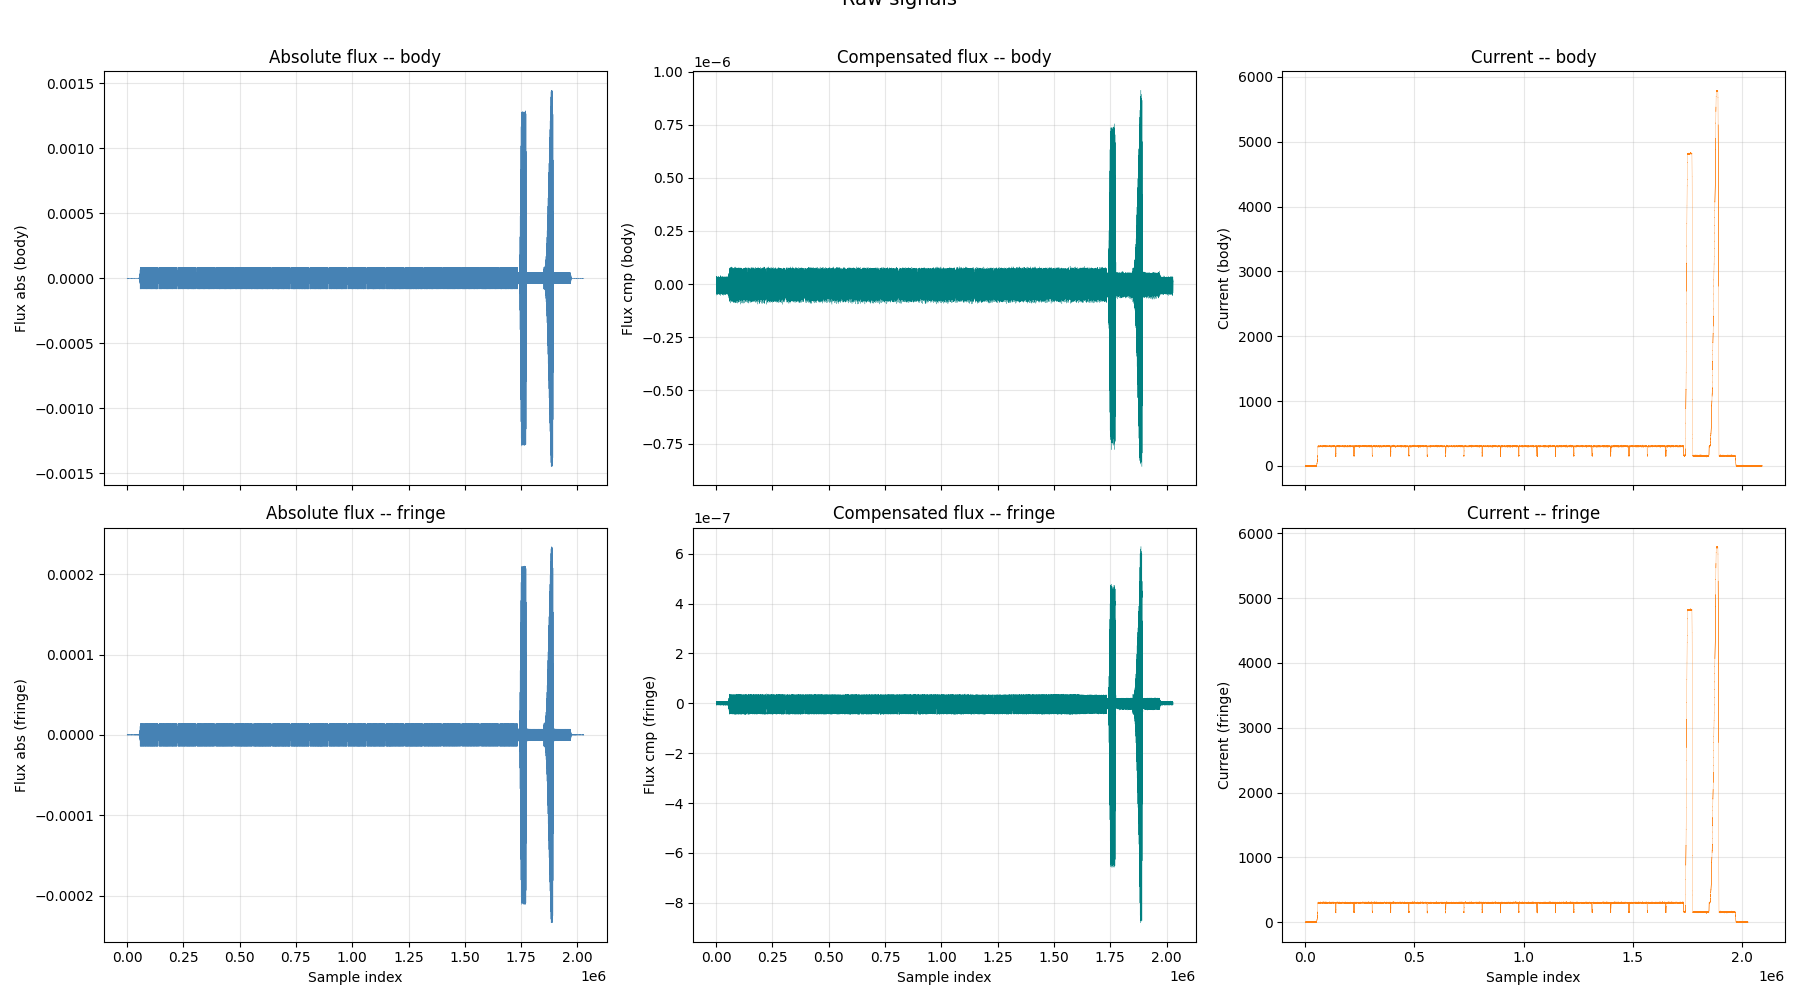

In [5]:
fig, axes = plt.subplots(len(SEGMENTS), 3, figsize=(18, 5 * len(SEGMENTS)), sharex="col")
if len(SEGMENTS) == 1:
    axes = axes[np.newaxis, :]

for i, seg in enumerate(SEGMENTS):
    d = data[seg]
    n_keep = d["n_turns"] * Ns
    x = np.arange(n_keep)
    axes[i, 0].plot(x, d["flux_abs"].ravel(), linewidth=0.2, color="steelblue")
    axes[i, 0].set_ylabel(f"Flux abs ({seg})")
    axes[i, 0].set_title(f"Absolute flux -- {seg}")
    axes[i, 1].plot(x, d["flux_cmp"].ravel(), linewidth=0.2, color="teal")
    axes[i, 1].set_ylabel(f"Flux cmp ({seg})")
    axes[i, 1].set_title(f"Compensated flux -- {seg}")
    axes[i, 2].plot(x, d["I_all"].ravel(), linewidth=0.2, color="tab:orange")
    axes[i, 2].set_ylabel(f"Current ({seg})")
    axes[i, 2].set_title(f"Current -- {seg}")

axes[-1, 0].set_xlabel("Sample index")
axes[-1, 1].set_xlabel("Sample index")
axes[-1, 2].set_xlabel("Sample index")
fig.suptitle("Raw signals", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` on CS high-current turns.

In [6]:
# Diagnostic on main segment (not fringe)
_main_seg = "body"
d = data[_main_seg]
I_mean = d["I_all"].mean(axis=1)
hi_mask = np.abs(I_mean) > np.percentile(np.abs(I_mean), 90)
if hi_mask.sum() < 5:
    hi_mask = np.abs(I_mean) > np.median(np.abs(I_mean))

n_diag = min(100, int(hi_mask.sum()))
if n_diag == 0:
    print(f"No high-I turns in {_main_seg} for cel/fed diagnostic -- skipping")
else:
    hi_idx = np.where(hi_mask)[0][:n_diag]

    diag = diagnose_cel_fed(
        d["flux_abs"][hi_idx], d["flux_cmp"][hi_idx],
        d["t_all"][hi_idx], d["I_all"][hi_idx],
        kn=KN[_main_seg], r_ref=R_REF, magnet_order=MAGNET_ORDER,
    )
    print(f"cel/fed diagnostic ({n_diag} {_main_seg} high-I turns):")
    print(f"  Recommendation: {diag.recommendation}")
    print(f"  {diag.reason}")
    Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
    print(f"  B_main max |diff|: {Bd:.4e} T")

    if diag.recommendation == "UNSAFE":
        OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
        print(f"  -> cel/fed disabled, OPTIONS = {OPTIONS}")
    else:
        print(f"  -> cel/fed safe, keeping OPTIONS = {OPTIONS}")

cel/fed diagnostic (100 body high-I turns):
  Recommendation: UNSAFE
  97/100 turns (97%) have |zR| > 0.0100 (median 0.0637, max 0.5891). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 1.4231e-05 T
  -> cel/fed disabled, OPTIONS = ('dri', 'rot')


---
## 6. Plateau Detection & Turn Classification


body: 1930 plateau, 21 inj groups, 2 flat-high groups
  injection   : 1562 turns, I = 300.9 +/- 0.1 A
  flat-high   :   26 turns, I = 5075.7 +/- 428.0 A
  ramp        :  114 turns

fringe [FRINGE]: 1866 plateau, 21 inj groups, 2 flat-high groups
  injection   : 1562 turns, I = 300.9 +/- 0.1 A
  flat-high   :   26 turns, I = 5075.7 +/- 428.0 A
  ramp        :  115 turns


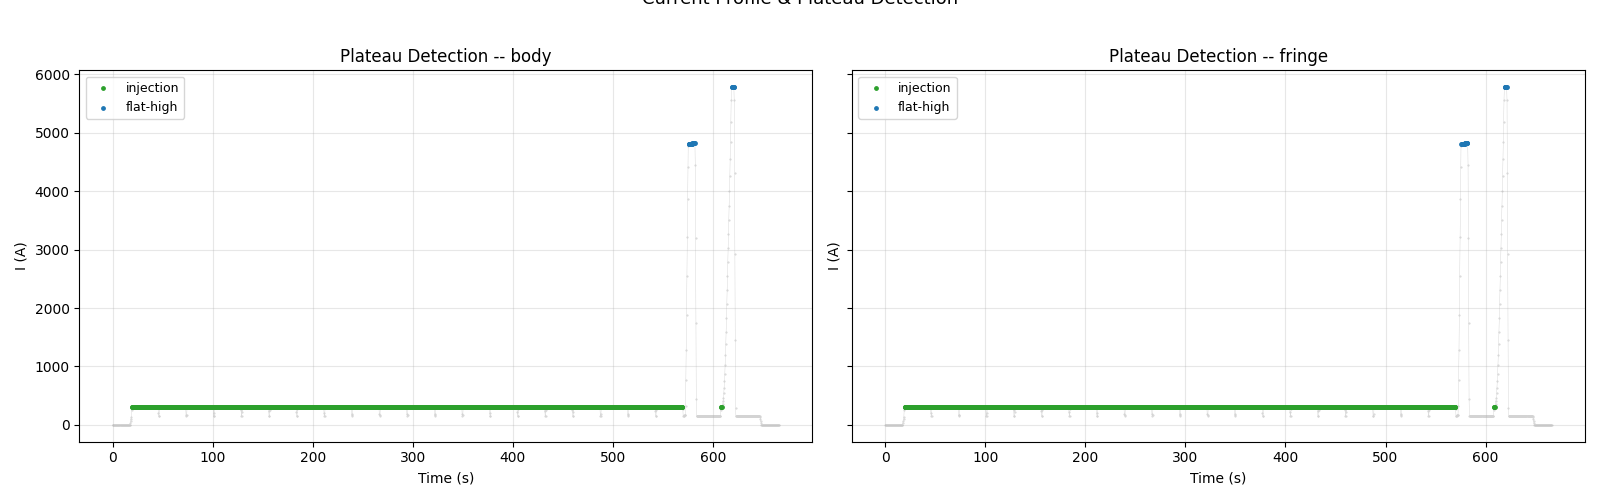

In [7]:
label_colors = {"injection": "tab:green", "flat-mid": "tab:purple", "flat-high": "tab:blue"}

for seg in SEGMENTS:
    d = data[seg]
    I_mean = d["I_all"].mean(axis=1)
    t_mean = d["t_all"].mean(axis=1)
    I_range, I_blocks = compute_block_averaged_range(d["I_all"], Ns, N_BLOCKS)

    plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
    is_plateau = plateau_info["is_plateau"]

    turn_label = np.array(["ramp"] * d["n_turns"], dtype=object)
    for j in range(d["n_turns"]):
        if is_plateau[j]:
            turn_label[j] = classify_current(I_mean[j])

    inj_groups = find_contiguous_groups(turn_label == "injection", min_length=2)
    fh_groups = find_contiguous_groups(turn_label == "flat-high", min_length=2)

    d.update({
        "I_mean": I_mean, "t_mean": t_mean, "I_range": I_range,
        "is_plateau": is_plateau, "turn_label": turn_label,
        "inj_groups": inj_groups, "fh_groups": fh_groups,
    })

    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [FRINGE]" if _scfg["is_fringe"] else ""
    print(f"\n{seg}{fringe}: {is_plateau.sum()} plateau, "
          f"{len(inj_groups)} inj groups, {len(fh_groups)} flat-high groups")
    for lab in ["injection", "flat-mid", "flat-high"]:
        mask = turn_label == lab
        if mask.sum() > 0:
            print(f"  {lab:12s}: {mask.sum():4d} turns, I = {I_mean[mask].mean():.1f} +/- {I_mean[mask].std():.1f} A")
    print(f"  {'ramp':12s}: {(turn_label == 'ramp').sum():4d} turns")

# Plot
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 5), sharey=True)
if len(SEGMENTS) == 1:
    axes = [axes]
for ax, seg in zip(axes, SEGMENTS):
    d = data[seg]
    ax.plot(d["t_mean"], d["I_mean"], ".-", markersize=1, linewidth=0.3, color="lightgrey", zorder=0)
    for lab, col in label_colors.items():
        mask = d["turn_label"] == lab
        idx = np.where(mask)[0]
        if len(idx) > 0:
            ax.scatter(d["t_mean"][idx], d["I_mean"][idx], s=6, color=col, zorder=2, label=lab)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("I (A)")
    ax.set_title(f"Plateau Detection -- {seg}"); ax.legend(fontsize=9)
fig.suptitle("Current Profile & Plateau Detection", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 7. FDI Stuck-Channel Diagnostic

Check whether the FDI responds to current changes between plateau groups.

In [8]:
for seg in SEGMENTS:
    d = data[seg]
    # Build run_info from contiguous plateau groups
    all_groups = []
    for lab_name in ["injection", "flat-mid", "flat-high"]:
        groups = find_contiguous_groups(d["turn_label"] == lab_name, min_length=2)
        for gs, ge in groups:
            all_groups.append({"start": gs, "end": ge,
                               "I_nom": float(d["I_mean"][gs:ge+1].mean())})
    all_groups.sort(key=lambda x: x["start"])
    for i, g in enumerate(all_groups):
        g["run_id"] = i

    if len(all_groups) < 2:
        print(f"{seg}: fewer than 2 plateau groups, skipping FDI check")
        continue

    flux_turns = d["flux_abs"].mean(axis=1)
    checks = diagnose_fdi_transitions(
        flux_turns, d["I_mean"], all_groups,
        stuck_threshold=0.3, partial_threshold=0.7, min_delta_I=5.0,
    )
    n_ok = sum(1 for c in checks if c.severity == "OK")
    n_stuck = sum(1 for c in checks if c.severity == "STUCK")
    print(f"\n{seg}: {len(checks)} transitions, OK={n_ok}, STUCK={n_stuck}")
    for c in checks:
        if c.severity != "OK":
            print(f"  ! Run {c.run_before}->{c.run_after}: {c.severity} -- {c.reason}")
    if n_stuck > 0:
        print(f"  WARNING: {n_stuck} stuck transitions!")
    else:
        print(f"  All transitions OK.")


body: 3 transitions, OK=3, STUCK=0
  All transitions OK.

fringe: 3 transitions, OK=3, STUCK=0
  All transitions OK.


C:\Users\albellel\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1437: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


---
## 8. Process Plateau Turns

Re-process plateau turns with the full pipeline. Group by supercycle/run, apply settling window and MAD sigma-clip.

In [9]:
ANALYSIS_LABELS = {"injection", "flat-mid", "flat-high"}

results = {}

for seg in SEGMENTS:
    d = data[seg]
    turn_label = d["turn_label"]
    kn_seg = KN[seg]

    is_analysis = np.array([l in ANALYSIS_LABELS for l in turn_label])
    plateau_indices = np.where(is_analysis)[0]
    print(f"\n{seg}: processing {len(plateau_indices)} plateau turns (OPTIONS={OPTIONS})")

    result, C_merged, C_units, ok_main = process_kn_pipeline(
        flux_abs_turns=d["flux_abs"][plateau_indices],
        flux_cmp_turns=d["flux_cmp"][plateau_indices],
        t_turns=d["t_all"][plateau_indices],
        I_turns=d["I_all"][plateau_indices],
        kn=kn_seg, r_ref=R_REF, magnet_order=m,
        options=OPTIONS, min_b1_T=MIN_B1_T,
    )

    extra = [
        {"global_turn": int(plateau_indices[t]),
          "label": str(turn_label[plateau_indices[t]]),
          "I_range_A": float(d["I_range"][plateau_indices[t]]),
          "segment": seg}
        for t in range(len(plateau_indices))
    ]

    rows = build_harmonic_rows(result, C_merged, C_units, ok_main, m, extra)
    df = pd.DataFrame(rows)

    # Group by supercycle
    df["sc_idx"] = -1
    settled_idx = []

    for gi, (gs, ge) in enumerate(d["inj_groups"]):
        group_globals = set(range(gs, ge + 1))
        gmask = df["global_turn"].isin(group_globals) & (df["label"] == "injection")
        df.loc[gmask, "sc_idx"] = gi
        group_rows = df.index[gmask]
        if N_LAST_TURNS_INJ is not None and len(group_rows) > N_LAST_TURNS_INJ:
            settled_idx.extend(group_rows[-N_LAST_TURNS_INJ:])
        else:
            settled_idx.extend(group_rows)

    for gi, (gs, ge) in enumerate(d["fh_groups"]):
        group_globals = set(range(gs, ge + 1))
        gmask = df["global_turn"].isin(group_globals) & (df["label"] == "flat-high")
        df.loc[gmask, "sc_idx"] = gi
        group_rows = df.index[gmask]
        if N_LAST_TURNS_HIGH is not None and len(group_rows) > N_LAST_TURNS_HIGH:
            settled_idx.extend(group_rows[-N_LAST_TURNS_HIGH:])
        else:
            settled_idx.extend(group_rows)

    df_settled = df.loc[sorted(settled_idx)].copy()

    n_before = len(df_settled)
    df_settled, clip_info = mad_sigma_clip(df_settled, "B1_T", N_SIGMA_CLIP, label_col="label")
    n_clipped = n_before - len(df_settled)
    if n_clipped > 0:
        print(f"  Sigma clip ({N_SIGMA_CLIP} MAD sigma): removed {n_clipped} turns ({clip_info})")

    df["TF_TperkA"] = df["B1_T"] / (df["I_mean_A"] / 1000.0)
    df_settled["TF_TperkA"] = df_settled["B1_T"] / (df_settled["I_mean_A"] / 1000.0)

    results[seg] = {"df": df, "df_settled": df_settled}

    print(f"  {seg}: {len(df)} all plateau, {len(df_settled)} settled")
    for lab in ["injection", "flat-high"]:
        n_all = len(df[df["label"] == lab])
        n_set = len(df_settled[df_settled["label"] == lab])
        print(f"    {lab:12s}: {n_all} -> {n_set}")


body: processing 1588 plateau turns (OPTIONS=('dri', 'rot'))


  Sigma clip (5.0 MAD sigma): removed 14 turns ({'injection': 7, 'flat-high': 7})
  body: 1588 all plateau, 375 settled
    injection   : 1562 -> 356
    flat-high   : 26 -> 19

fringe: processing 1588 plateau turns (OPTIONS=('dri', 'rot'))


  Sigma clip (5.0 MAD sigma): removed 10 turns ({'injection': 3, 'flat-high': 7})
  fringe: 1588 all plateau, 379 settled
    injection   : 1562 -> 360
    flat-high   : 26 -> 19


---
## 9. All-Turn Harmonics vs Time

Process all turns (including ramps) to show B1, b2, b3 evolution.

body: 2044 all-turns processed, ok_main=1981


fringe: 1981 all-turns processed, ok_main=1981


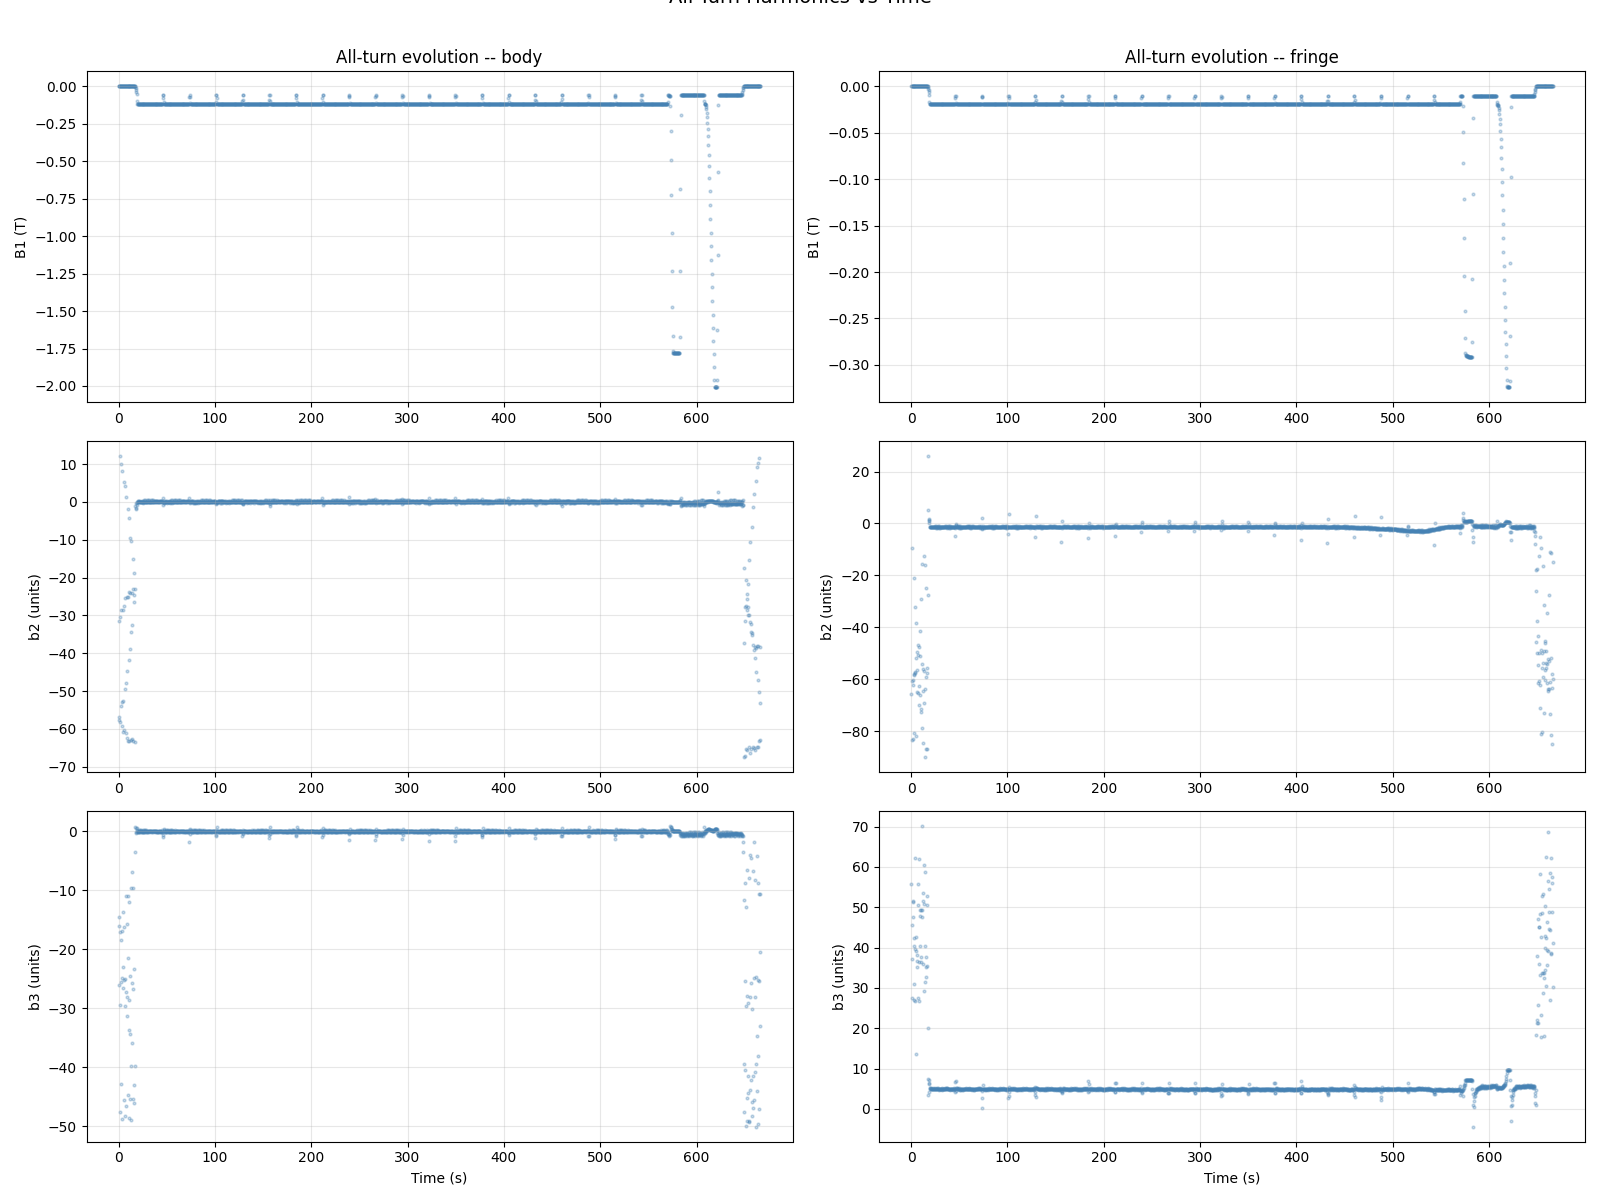

In [10]:
all_turn_dfs = {}

for seg in SEGMENTS:
    d = data[seg]
    kn_seg = KN[seg]

    result_all, C_merged_all, C_units_all, ok_main_all = process_kn_pipeline(
        flux_abs_turns=d["flux_abs"], flux_cmp_turns=d["flux_cmp"],
        t_turns=d["t_all"], I_turns=d["I_all"],
        kn=kn_seg, r_ref=R_REF, magnet_order=m,
        options=OPTIONS, min_b1_T=MIN_B1_T,
    )

    extra_all = [{"global_turn": int(i), "segment": seg} for i in range(d["n_turns"])]
    rows_all = build_harmonic_rows(result_all, C_merged_all, C_units_all, ok_main_all, m, extra_all)
    df_all = pd.DataFrame(rows_all)
    df_all["t_mean_s"] = d["t_mean"]
    all_turn_dfs[seg] = df_all
    print(f"{seg}: {d['n_turns']} all-turns processed, ok_main={ok_main_all.sum()}")

# Plot B1, b2, b3 vs time
fig, axes = plt.subplots(3, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 12))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

for j, seg in enumerate(SEGMENTS):
    df_all = all_turn_dfs[seg]
    ok = df_all["ok_main"]
    for ax_idx, (col, ylabel) in enumerate([("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)")]):
        ax = axes[ax_idx, j]
        ax.scatter(df_all.loc[ok, "t_mean_s"], df_all.loc[ok, col],
                   s=4, alpha=0.3, color="steelblue", zorder=1)
        ax.set_ylabel(ylabel)
        if ax_idx == 0:
            ax.set_title(f"All-turn evolution -- {seg}")
        if ax_idx == 2:
            ax.set_xlabel("Time (s)")

fig.suptitle("All-Turn Harmonics vs Time", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

---
## 10. FFMM Golden Standard Validation

Compare pipeline output against FFMM per-turn and average results.

In [11]:
OPTIONS_FFMM = ('dri', 'rot')
FFMM_ROTATE_EXCLUDES_LAST = True

print("=" * 70)
print("FFMM GOLDEN STANDARD COMPARISON")
print(f"FFMM pipeline options: {OPTIONS_FFMM}")
print(f"legacy_rotate_excludes_last = {FFMM_ROTATE_EXCLUDES_LAST}")
print("=" * 70)

bn_cols_ffmm = [f"b{n}(Units)" for n in range(2, 16)]
an_cols_ffmm = [f"a{n}(Units)" for n in range(2, 16)]

for seg in SEGMENTS:
    seg_cfg = [s for s in SEGMENT_CONFIGS if s["name"] == seg][0]
    ffmm_file = list(RUN_DIR.glob(f"*_{seg}_results.txt"))
    if not ffmm_file:
        print(f"  {seg}: no FFMM results file found -- skipping")
        continue
    ffmm = pd.read_csv(ffmm_file[0], sep="	")
    print()
    print(f"--- {seg} ({len(ffmm)} FFMM turns) ---")

    d = data[seg]
    kn_seg = KN[seg]

    res_ffmm, Cm_ffmm, Cu_ffmm, ok_ffmm = process_kn_pipeline(
        d["flux_abs"], d["flux_cmp"], d["t_all"], d["I_all"],
        kn=kn_seg, r_ref=R_REF, magnet_order=m,
        options=OPTIONS_FFMM, min_b1_T=MIN_B1_T,
        legacy_rotate_excludes_last=FFMM_ROTATE_EXCLUDES_LAST,
    )
    rows_gs = build_harmonic_rows(res_ffmm, Cm_ffmm, Cu_ffmm, ok_ffmm, m, [{}]*d["n_turns"])
    df_ours = pd.DataFrame(rows_gs)

    n_cmp = min(len(df_ours), len(ffmm))
    df_ours = df_ours.iloc[:n_cmp]
    ffmm_cmp = ffmm.iloc[:n_cmp]

    I_ffmm = ffmm_cmp["I(A)"].values
    hi = np.abs(I_ffmm) > 4000
    inj = (np.abs(I_ffmm) > 250) & (np.abs(I_ffmm) < 350)

    for mask_name, mask in [("flat-top", hi), ("injection", inj)]:
        if mask.sum() < 2:
            print(f"  {mask_name}: too few turns")
            continue
        for harm in ["b2", "b3", "b4", "b5"]:
            col_ffmm = f"{harm}(Units)"
            col_ours = f"{harm}_units"
            if col_ffmm not in ffmm_cmp.columns or col_ours not in df_ours.columns:
                continue
            v_ffmm = ffmm_cmp.loc[mask, col_ffmm].values
            v_ours = df_ours.loc[mask, col_ours].values
            ok_both = ~np.isnan(v_ffmm) & ~np.isnan(v_ours) & df_ours.loc[mask, "ok_main"].values
            if ok_both.sum() == 0:
                continue
            diff = v_ours[ok_both] - v_ffmm[ok_both]
            print(f"  {mask_name:10s} {harm}: FFMM={v_ffmm[ok_both].mean():+8.4f}  ours={v_ours[ok_both].mean():+8.4f}  diff={diff.mean():+.4f} +/- {diff.std():.4f} units  (N={ok_both.sum()})")

    B_main_ffmm = ffmm_cmp["B_main(T)"].values
    B1_ours = np.array([Cm_ffmm[i][0].real if i < len(Cm_ffmm) else np.nan for i in range(n_cmp)])
    for mask_name, mask in [("flat-top", hi), ("injection", inj)]:
        if mask.sum() < 2: continue
        ok_b = mask & ~np.isnan(B1_ours[:n_cmp])
        diff_B = B1_ours[ok_b] - B_main_ffmm[ok_b]
        print(f"  {mask_name:10s} B1:  FFMM={B_main_ffmm[ok_b].mean():.6f} T  ours={B1_ours[ok_b].mean():.6f} T  diff={diff_B.mean()*1e6:.1f} uT")


FFMM GOLDEN STANDARD COMPARISON
FFMM pipeline options: ('dri', 'rot')
legacy_rotate_excludes_last = True

--- body (1980 FFMM turns) ---
  flat-top   b2: FFMM= +0.0354  ours= +0.0354  diff=+0.0000 +/- 0.0000 units  (N=38)
  flat-top   b3: FFMM= +0.0918  ours= +0.0918  diff=-0.0000 +/- 0.0000 units  (N=38)
  flat-top   b4: FFMM= -0.0197  ours= -0.0197  diff=-0.0000 +/- 0.0000 units  (N=38)
  flat-top   b5: FFMM= +0.0030  ours= +0.0030  diff=-0.0000 +/- 0.0000 units  (N=38)
  injection  b2: FFMM= +0.0814  ours= +0.0814  diff=+0.0000 +/- 0.0000 units  (N=1587)
  injection  b3: FFMM= -0.0036  ours= -0.0036  diff=-0.0000 +/- 0.0000 units  (N=1587)
  injection  b4: FFMM= +0.0286  ours= +0.0286  diff=+0.0000 +/- 0.0000 units  (N=1587)
  injection  b5: FFMM= -0.0263  ours= -0.0263  diff=-0.0000 +/- 0.0000 units  (N=1587)
  flat-top   B1:  FFMM=-1.824248 T  ours=-1.824248 T  diff=0.0 uT
  injection  B1:  FFMM=-0.115536 T  ours=-0.115536 T  diff=0.0 uT



--- fringe (1980 FFMM turns) ---
  flat-top   b2: FFMM= +0.5978  ours= +0.5978  diff=-0.0000 +/- 0.0000 units  (N=38)
  flat-top   b3: FFMM= +7.7620  ours= +7.7620  diff=+0.0000 +/- 0.0000 units  (N=38)
  flat-top   b4: FFMM= +0.2044  ours= +0.2044  diff=+0.0000 +/- 0.0000 units  (N=38)
  flat-top   b5: FFMM= +0.8695  ours= +0.8695  diff=+0.0000 +/- 0.0000 units  (N=38)
  injection  b2: FFMM= -1.4867  ours= -1.4867  diff=+0.0000 +/- 0.0000 units  (N=1587)
  injection  b3: FFMM= +4.9049  ours= +4.9049  diff=-0.0000 +/- 0.0000 units  (N=1587)
  injection  b4: FFMM= -0.2001  ours= -0.2001  diff=+0.0000 +/- 0.0000 units  (N=1587)
  injection  b5: FFMM= +0.3323  ours= +0.3323  diff=-0.0000 +/- 0.0000 units  (N=1587)
  flat-top   B1:  FFMM=-0.296873 T  ours=-0.296873 T  diff=0.0 uT
  injection  B1:  FFMM=-0.019549 T  ours=-0.019549 T  diff=-0.0 uT


---
## 11. Main Field (B1)

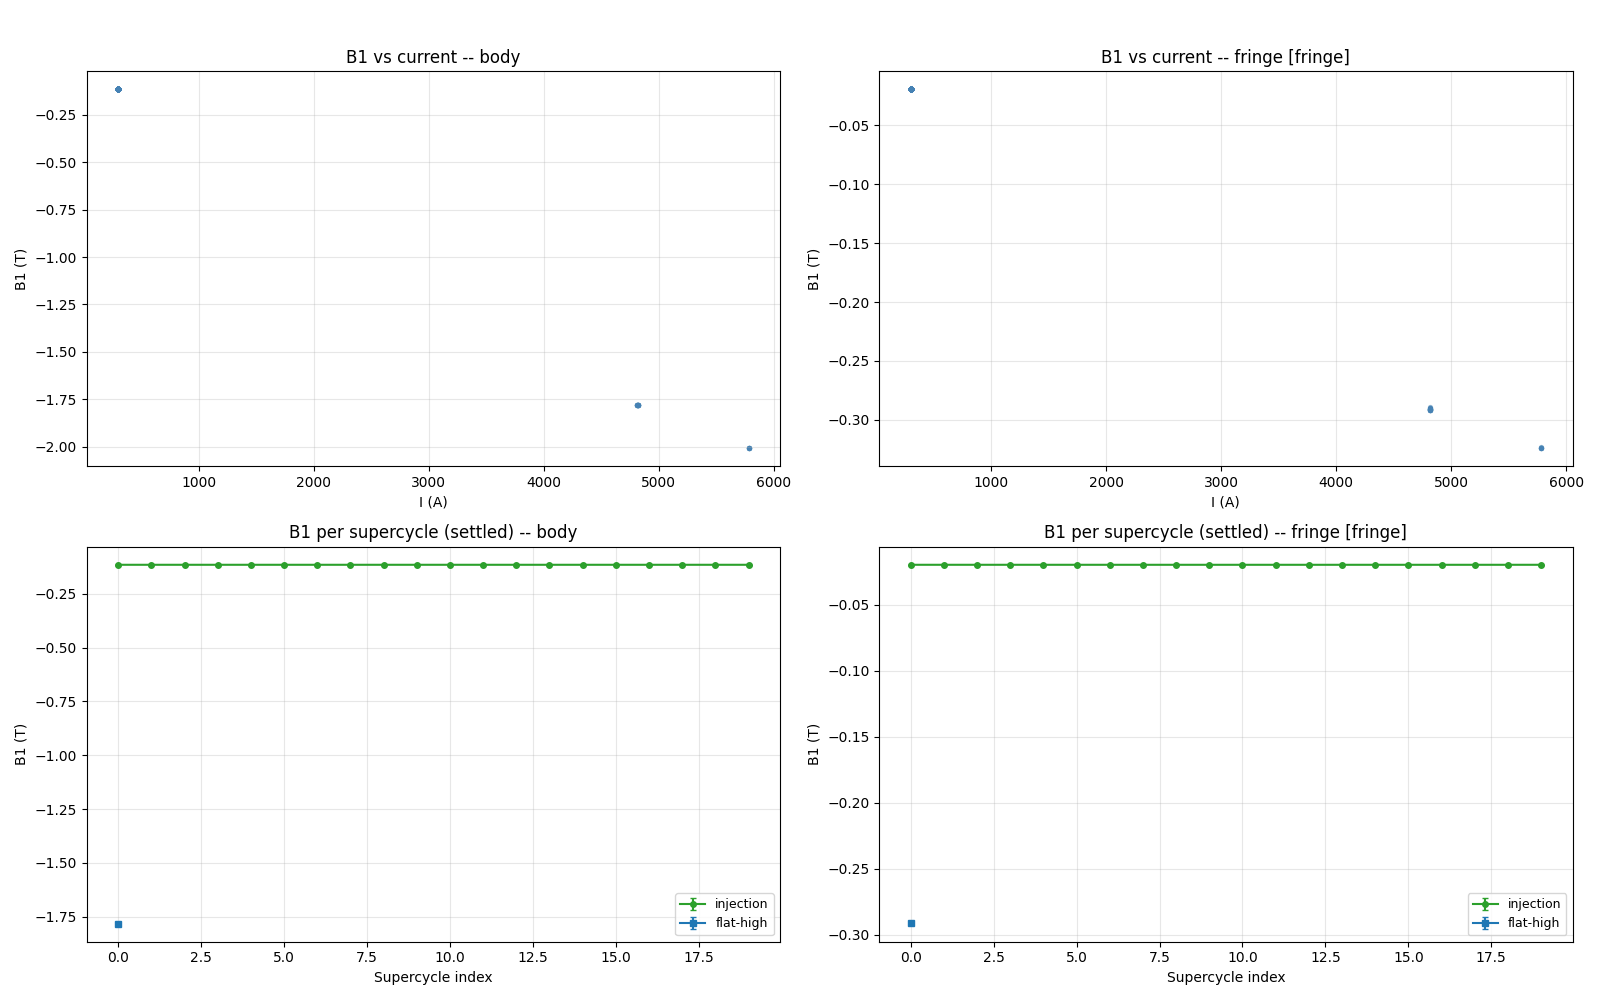


B1 per operating point (settled turns):
  body injection   : N= 356, mean=-0.115623, std=0.000007
  body flat-high   : N=  19, mean=-1.781262, std=0.001141
  fringe injection   : N= 360, mean=-0.019564, std=0.000003
  fringe flat-high   : N=  19, mean=-0.290912, std=0.000591


In [12]:
fig, axes = plt.subplots(2, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 10))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

for j, seg in enumerate(SEGMENTS):
    df = results[seg]["df"]
    df_settled = results[seg]["df_settled"]
    ok = df["ok_main"]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [fringe]" if _scfg["is_fringe"] else ""

    ax = axes[0, j]
    ax.scatter(df.loc[ok, "I_mean_A"], df.loc[ok, "B1_T"], s=8, alpha=0.5, color="steelblue")
    
    ax.set_xlabel("I (A)"); ax.set_ylabel("B1 (T)")
    ax.set_title(f"B1 vs current -- {seg}{fringe}")

    ax = axes[1, j]
    for lab, col, marker in [("injection", "tab:green", "o"), ("flat-high", "tab:blue", "s")]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            sc_avg = sub.groupby("sc_idx")["B1_T"].agg(["mean", "std"]).reset_index()
            ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                        fmt=f"{marker}-", markersize=4, capsize=2, color=col, label=lab)
    
    ax.set_xlabel("Supercycle index"); ax.set_ylabel("B1 (T)")
    ax.set_title(f"B1 per supercycle (settled) -- {seg}{fringe}"); ax.legend(fontsize=9)

fig.suptitle("Main Field (B1)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Statistics
print("\nB1 per operating point (settled turns):")
for seg in SEGMENTS:
    df_settled = results[seg]["df_settled"]
    for lab in ["injection", "flat-high"]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            print(f"  {seg} {lab:12s}: N={len(sub):4d}, mean={sub['B1_T'].mean():+.6f}, std={sub['B1_T'].std():.6f}")

---
## 12. b2 (Quadrupole) -- first allowed harmonic error

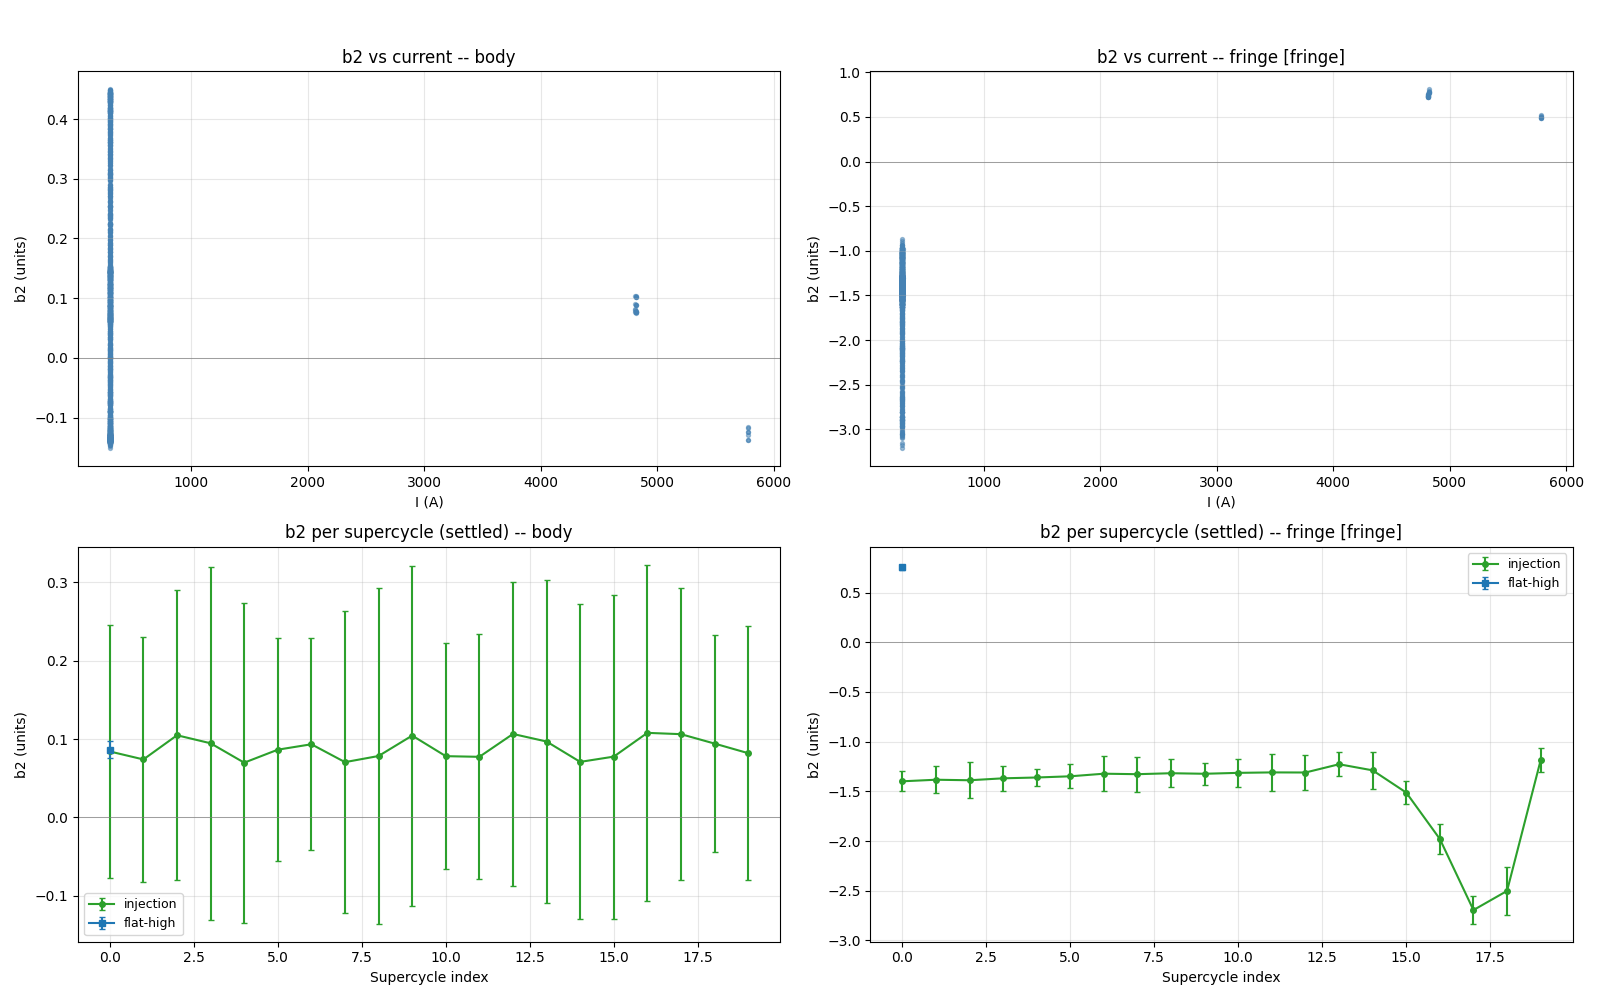


b2 per operating point (settled turns):
  body injection   : N= 356, mean=+0.087959, std=0.180051
  body flat-high   : N=  19, mean=+0.086603, std=0.011027
  fringe injection   : N= 360, mean=-1.493093, std=0.426737
  fringe flat-high   : N=  19, mean=+0.753956, std=0.024949


In [13]:
fig, axes = plt.subplots(2, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 10))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

for j, seg in enumerate(SEGMENTS):
    df = results[seg]["df"]
    df_settled = results[seg]["df_settled"]
    ok = df["ok_main"]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [fringe]" if _scfg["is_fringe"] else ""

    ax = axes[0, j]
    ax.scatter(df.loc[ok, "I_mean_A"], df.loc[ok, "b2_units"], s=8, alpha=0.5, color="steelblue")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel("I (A)"); ax.set_ylabel("b2 (units)")
    ax.set_title(f"b2 vs current -- {seg}{fringe}")

    ax = axes[1, j]
    for lab, col, marker in [("injection", "tab:green", "o"), ("flat-high", "tab:blue", "s")]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            sc_avg = sub.groupby("sc_idx")["b2_units"].agg(["mean", "std"]).reset_index()
            ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                        fmt=f"{marker}-", markersize=4, capsize=2, color=col, label=lab)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel("Supercycle index"); ax.set_ylabel("b2 (units)")
    ax.set_title(f"b2 per supercycle (settled) -- {seg}{fringe}"); ax.legend(fontsize=9)

fig.suptitle("b2 (Quadrupole) -- first allowed harmonic error", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Statistics
print("\nb2 per operating point (settled turns):")
for seg in SEGMENTS:
    df_settled = results[seg]["df_settled"]
    for lab in ["injection", "flat-high"]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            print(f"  {seg} {lab:12s}: N={len(sub):4d}, mean={sub['b2_units'].mean():+.6f}, std={sub['b2_units'].std():.6f}")

---
## 13. b3 (Sextupole) -- first non-allowed harmonic

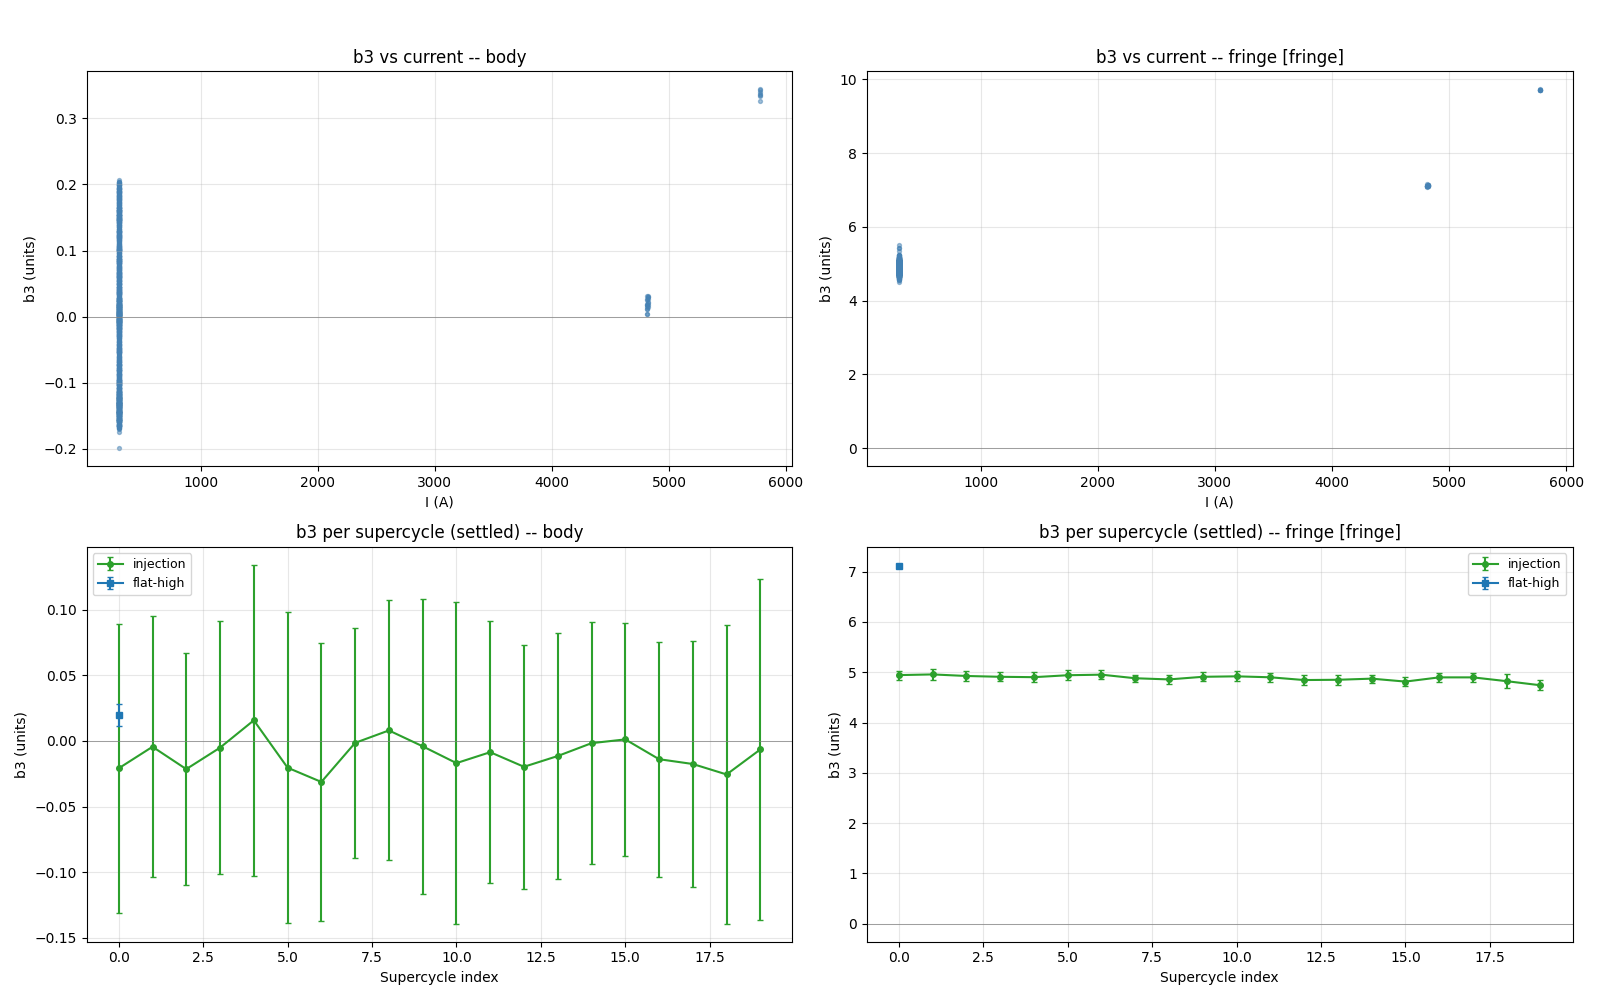


b3 per operating point (settled turns):
  body injection   : N= 356, mean=-0.010170, std=0.101198
  body flat-high   : N=  19, mean=+0.019786, std=0.008591
  fringe injection   : N= 360, mean=+4.887050, std=0.105567
  fringe flat-high   : N=  19, mean=+7.118958, std=0.017502


In [14]:
fig, axes = plt.subplots(2, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 10))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

for j, seg in enumerate(SEGMENTS):
    df = results[seg]["df"]
    df_settled = results[seg]["df_settled"]
    ok = df["ok_main"]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [fringe]" if _scfg["is_fringe"] else ""

    ax = axes[0, j]
    ax.scatter(df.loc[ok, "I_mean_A"], df.loc[ok, "b3_units"], s=8, alpha=0.5, color="steelblue")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel("I (A)"); ax.set_ylabel("b3 (units)")
    ax.set_title(f"b3 vs current -- {seg}{fringe}")

    ax = axes[1, j]
    for lab, col, marker in [("injection", "tab:green", "o"), ("flat-high", "tab:blue", "s")]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            sc_avg = sub.groupby("sc_idx")["b3_units"].agg(["mean", "std"]).reset_index()
            ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                        fmt=f"{marker}-", markersize=4, capsize=2, color=col, label=lab)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel("Supercycle index"); ax.set_ylabel("b3 (units)")
    ax.set_title(f"b3 per supercycle (settled) -- {seg}{fringe}"); ax.legend(fontsize=9)

fig.suptitle("b3 (Sextupole) -- first non-allowed harmonic", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# Statistics
print("\nb3 per operating point (settled turns):")
for seg in SEGMENTS:
    df_settled = results[seg]["df_settled"]
    for lab in ["injection", "flat-high"]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            print(f"  {seg} {lab:12s}: N={len(sub):4d}, mean={sub['b3_units'].mean():+.6f}, std={sub['b3_units'].std():.6f}")

---
## 14. Higher Harmonics Overview

Statistics for all harmonics at key operating points (CS).

In [15]:
seg = "body"
df_settled = results[seg]["df_settled"]
ok = df_settled["ok_main"]

for lab in ["injection", "flat-high"]:
    sub = df_settled[(df_settled["label"] == lab) & ok]
    if len(sub) == 0:
        continue
    print(f"\n=== {lab.upper()} (N={len(sub)} settled turns, {seg}) ===")
    print(f"  {'n':>3s} {'bn mean':>10s} {'bn std':>10s} {'an mean':>10s} {'an std':>10s}")
    print("  " + "-" * 50)
    for nn in range(2, H + 1):
        bn_col = f"b{nn}_units"
        an_col = f"a{nn}_units"
        if bn_col in sub.columns:
            bn_m, bn_s = sub[bn_col].mean(), sub[bn_col].std()
            an_m, an_s = sub[an_col].mean(), sub[an_col].std()
            flag = " *" if abs(bn_m) > 2 * bn_s and abs(bn_m) > 0.5 else ""
            print(f"  {nn:3d} {bn_m:+10.4f} {bn_s:10.4f} {an_m:+10.4f} {an_s:10.4f}{flag}")
    print("  (* = |mean| > 2*std and |mean| > 0.5 units)")


=== INJECTION (N=356 settled turns, body) ===
    n    bn mean     bn std    an mean     an std
  --------------------------------------------------
    2    +0.0880     0.1801    +0.3833     0.1020
    3    -0.0102     0.1012    -0.1182     0.0417
    4    +0.0322     0.0851    -0.0519     0.0255
    5    -0.0292     0.0829    -0.0074     0.0210
    6    -0.0010     0.0889    +0.0049     0.0239
    7    +0.0850     0.0982    +0.0453     0.0244
    8    -0.0010     0.1134    +0.0268     0.0266
    9    -0.1050     0.1300    +0.0026     0.0350
   10    +0.0084     0.1544    +0.0056     0.0439
   11    +0.0956     0.1916    +0.0336     0.0532
   12    -0.0646     0.2290    +0.0025     0.0676
   13    -0.0561     0.2869    -0.0462     0.0957
   14    +0.0159     0.3580    +0.0745     0.1157
   15    +0.2504     0.4440    -0.0091     0.1506
  (* = |mean| > 2*std and |mean| > 0.5 units)

=== FLAT-HIGH (N=19 settled turns, body) ===
    n    bn mean     bn std    an mean     an std
  ------

---
## 15. Multipole Spectrum

Bar charts of normal (bn) and skew (an) harmonics.

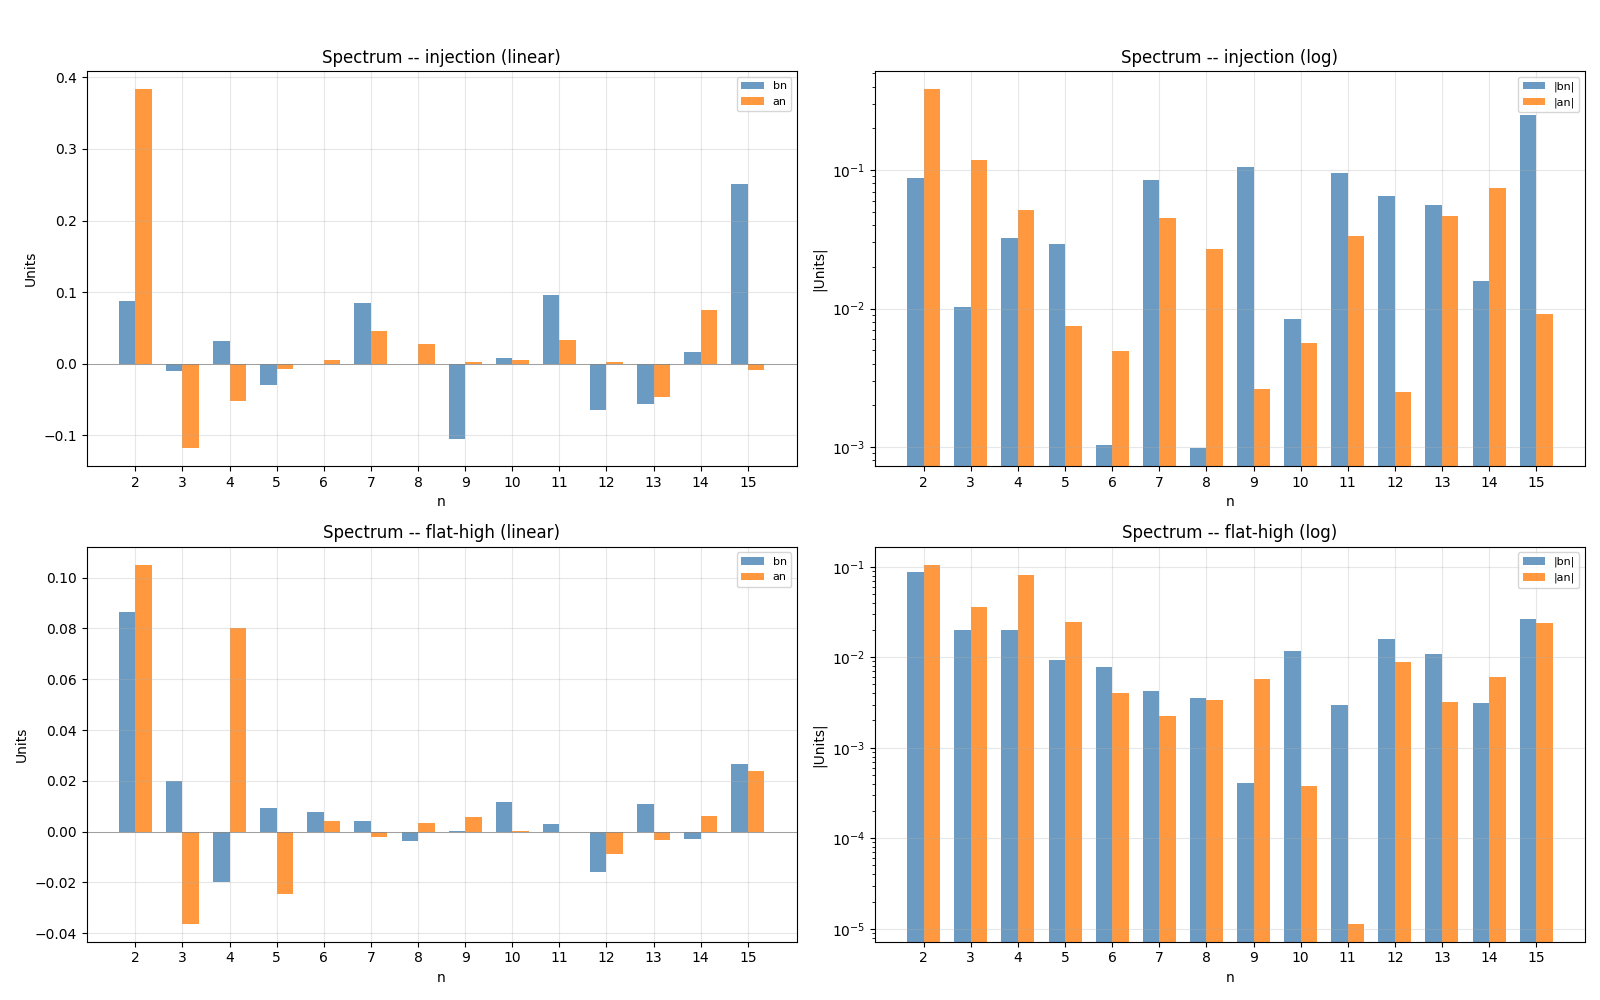

In [16]:
seg = "body"
df_settled = results[seg]["df_settled"]
ok = df_settled["ok_main"]

operating_points = {}
for lab in ["injection", "flat-high"]:
    sub = df_settled[(df_settled["label"] == lab) & ok]
    if len(sub) > 0:
        operating_points[lab] = sub

n_ops = len(operating_points)
if n_ops > 0:
    fig, axes = plt.subplots(n_ops, 2, figsize=(16, 5 * n_ops))
    if n_ops == 1:
        axes = axes[np.newaxis, :]

    for i, (lab, sub) in enumerate(operating_points.items()):
        orders = list(range(2, H + 1))
        bn_means = [sub[f"b{nn}_units"].mean() for nn in orders]
        an_means = [sub[f"a{nn}_units"].mean() for nn in orders]
        x = np.arange(len(orders))
        w = 0.35

        ax = axes[i, 0]
        ax.bar(x - w/2, bn_means, w, label="bn", color="steelblue", alpha=0.8)
        ax.bar(x + w/2, an_means, w, label="an", color="tab:orange", alpha=0.8)
        ax.axhline(0, color="grey", linewidth=0.5)
        ax.set_xticks(x); ax.set_xticklabels(orders)
        ax.set_xlabel("n"); ax.set_ylabel("Units")
        ax.set_title(f"Spectrum -- {lab} (linear)"); ax.legend(fontsize=8)

        ax = axes[i, 1]
        ax.bar(x - w/2, np.abs(bn_means), w, label="|bn|", color="steelblue", alpha=0.8)
        ax.bar(x + w/2, np.abs(an_means), w, label="|an|", color="tab:orange", alpha=0.8)
        ax.set_yscale("log")
        ax.set_xticks(x); ax.set_xticklabels(orders)
        ax.set_xlabel("n"); ax.set_ylabel("|Units|")
        ax.set_title(f"Spectrum -- {lab} (log)"); ax.legend(fontsize=8)

    fig.suptitle("Multipole Spectrum", fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("No operating points with data for spectrum plot.")

---
## 16. Transfer Function B1/I

TF = B1 / I (units: T/kA).

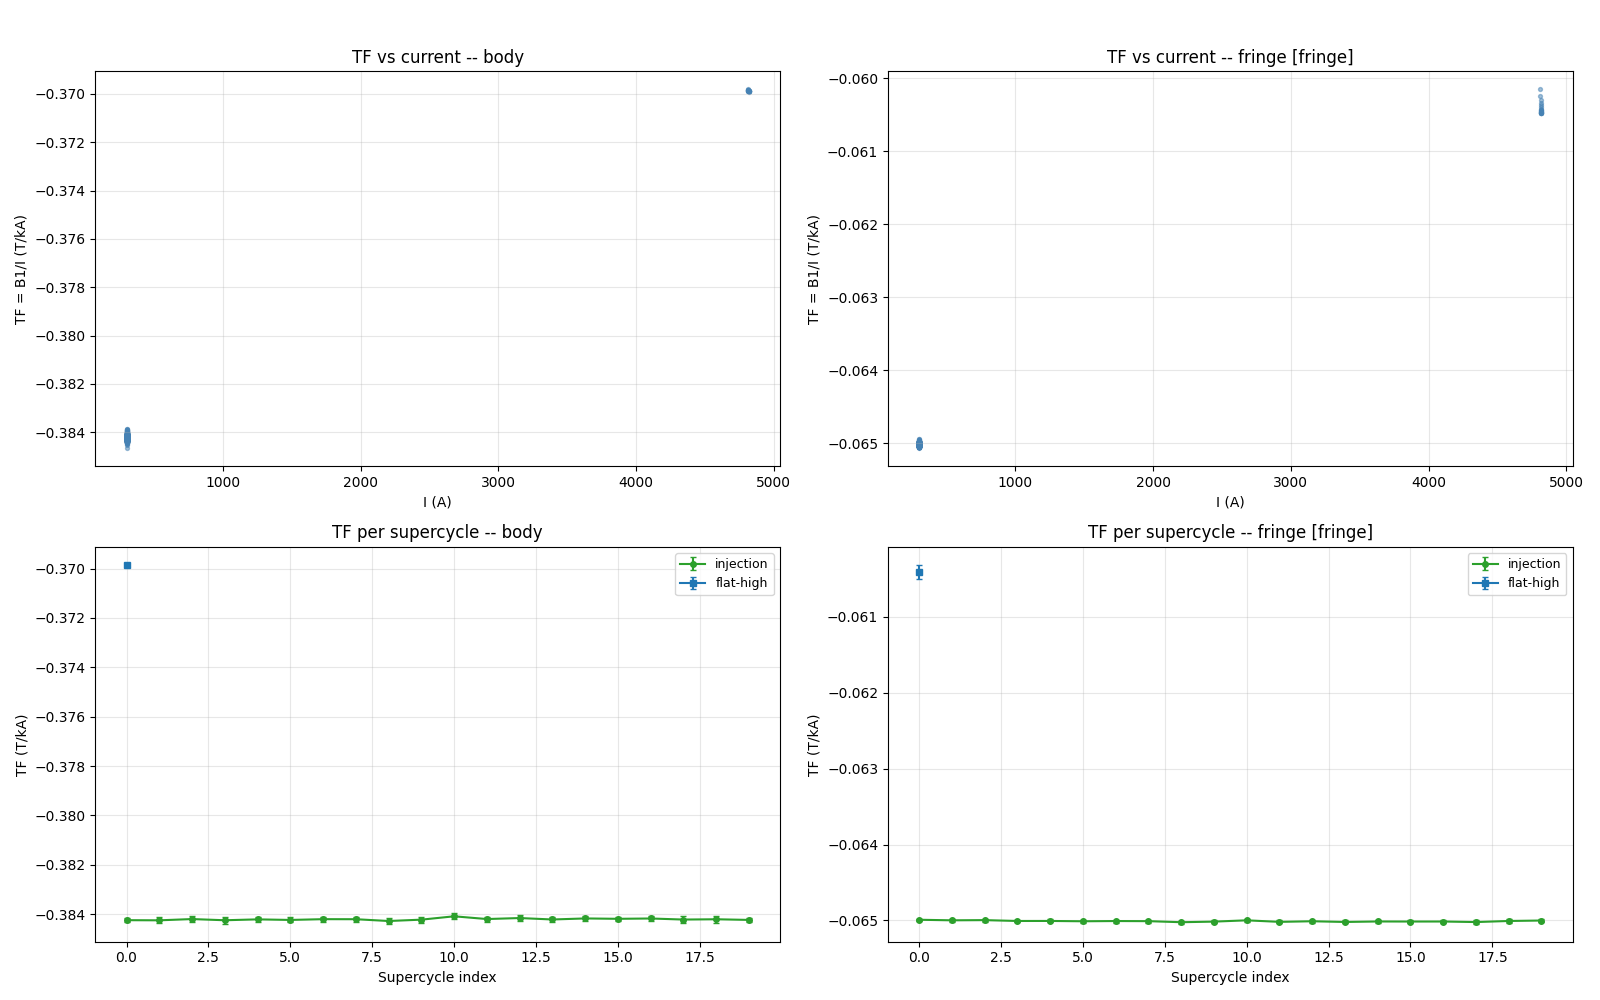

In [17]:
fig, axes = plt.subplots(2, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 10))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

tf_summary = {}
for j, seg in enumerate(SEGMENTS):
    df_settled = results[seg]["df_settled"]
    ok = df_settled["ok_main"]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [fringe]" if _scfg["is_fringe"] else ""

    ax = axes[0, j]
    sub_ok = df_settled[ok]
    ax.scatter(sub_ok["I_mean_A"], sub_ok["TF_TperkA"], s=8, alpha=0.5, color="steelblue")
    ax.set_xlabel("I (A)"); ax.set_ylabel("TF = B1/I (T/kA)")
    ax.set_title(f"TF vs current -- {seg}{fringe}")

    ax = axes[1, j]
    ds_tf = {}
    for lab, col, marker in [("injection", "tab:green", "o"), ("flat-high", "tab:blue", "s")]:
        sub = df_settled[(df_settled["label"] == lab) & ok]
        if len(sub) > 0:
            sc_avg = sub.groupby("sc_idx")["TF_TperkA"].agg(["mean", "std"]).reset_index()
            ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                        fmt=f"{marker}-", markersize=4, capsize=2, color=col, label=lab)
            ds_tf[lab] = sc_avg
    ax.set_xlabel("Supercycle index"); ax.set_ylabel("TF (T/kA)")
    ax.set_title(f"TF per supercycle -- {seg}{fringe}"); ax.legend(fontsize=9)
    tf_summary[seg] = ds_tf

fig.suptitle("Transfer Function B1/I", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## 17. Apparent vs Differential Inductance

**L_app** = B1/I, **L_d** = dB1/dI (from paired current levels).

In [18]:
ld_results = {}
for seg in SEGMENTS:
    df_settled = results[seg]["df_settled"]
    ok = df_settled["ok_main"]
    df_inj = df_settled[(df_settled["label"] == "injection") & ok]
    df_fh = df_settled[(df_settled["label"] == "flat-high") & ok]

    if len(df_inj) == 0 or len(df_fh) == 0:
        ld_results[seg] = pd.DataFrame()
        continue

    inj_avg = df_inj.groupby("sc_idx").agg(
        B1_inj=("B1_T", "mean"), I_inj=("I_mean_A", "mean")).reset_index()
    fh_avg = df_fh.groupby("sc_idx").agg(
        B1_fh=("B1_T", "mean"), I_fh=("I_mean_A", "mean")).reset_index()

    merged = inj_avg.merge(fh_avg, on="sc_idx", how="inner")
    if len(merged) == 0:
        ld_results[seg] = pd.DataFrame()
        continue

    merged["Ld_TperkA"] = (merged["B1_fh"] - merged["B1_inj"]) / ((merged["I_fh"] - merged["I_inj"]) / 1000.0)
    ld_results[seg] = merged
    print(f"{seg}: {len(merged)} SC pairs, "
          f"Ld = {merged['Ld_TperkA'].mean():.4f} +/- {merged['Ld_TperkA'].std():.4f} T/kA")

print("\nSaturation check (Ld < L_app(FT) => saturated):")
for seg in SEGMENTS:
    m_df = ld_results.get(seg, pd.DataFrame())
    if len(m_df) == 0:
        continue
    Ld_mean = m_df["Ld_TperkA"].mean()
    fh = results[seg]["df_settled"]
    fh_ok = fh[(fh["label"] == "flat-high") & fh["ok_main"]]
    if len(fh_ok) > 0:
        Lapp_fh = fh_ok["TF_TperkA"].mean()
        ratio = Ld_mean / Lapp_fh
        verdict = "SATURATED" if ratio < 0.99 else "LINEAR"
        print(f"  {seg}: Ld={Ld_mean:.4f}, L_app(FT)={Lapp_fh:.4f}, ratio={ratio:.4f} -> {verdict}")

body: 1 SC pairs, Ld = -0.3689 +/- nan T/kA
fringe: 1 SC pairs, Ld = -0.0601 +/- nan T/kA

Saturation check (Ld < L_app(FT) => saturated):
  body: Ld=-0.3689, L_app(FT)=-0.3699, ratio=0.9974 -> LINEAR
  fringe: Ld=-0.0601, L_app(FT)=-0.0604, ratio=0.9949 -> LINEAR


---
## 18. Eddy Current Settling Analysis

Turn-by-turn B1 for all runs. Eddy currents cause exponential decay.

In [19]:
# Build per-supercycle injection data
eddy_data = {}

for seg in SEGMENTS:
    d = data[seg]
    df = results[seg]["df"]
    inj = df[df["label"] == "injection"].copy()
    if len(inj) == 0:
        eddy_data[seg] = pd.DataFrame()
        continue

    inj["t_mean_s"] = d["t_mean"][inj["global_turn"].values]
    for sc_id in inj["sc_idx"].unique():
        if sc_id < 0: continue
        mask = inj["sc_idx"] == sc_id
        t0 = inj.loc[mask, "t_mean_s"].min()
        inj.loc[mask, "t_since_inj_start"] = inj.loc[mask, "t_mean_s"] - t0

    for sc_id in inj["sc_idx"].unique():
        if sc_id < 0: continue
        mask = inj["sc_idx"] == sc_id
        inj.loc[mask, "turn_in_group"] = np.arange(mask.sum())

    eddy_data[seg] = inj
    print(f"{seg}: {len(inj)} injection turns across {inj['sc_idx'].nunique()} supercycles")

body: 1562 injection turns across 21 supercycles
fringe: 1562 injection turns across 21 supercycles


### Settling curves -- Mean Ã‚Â± STD across supercycles

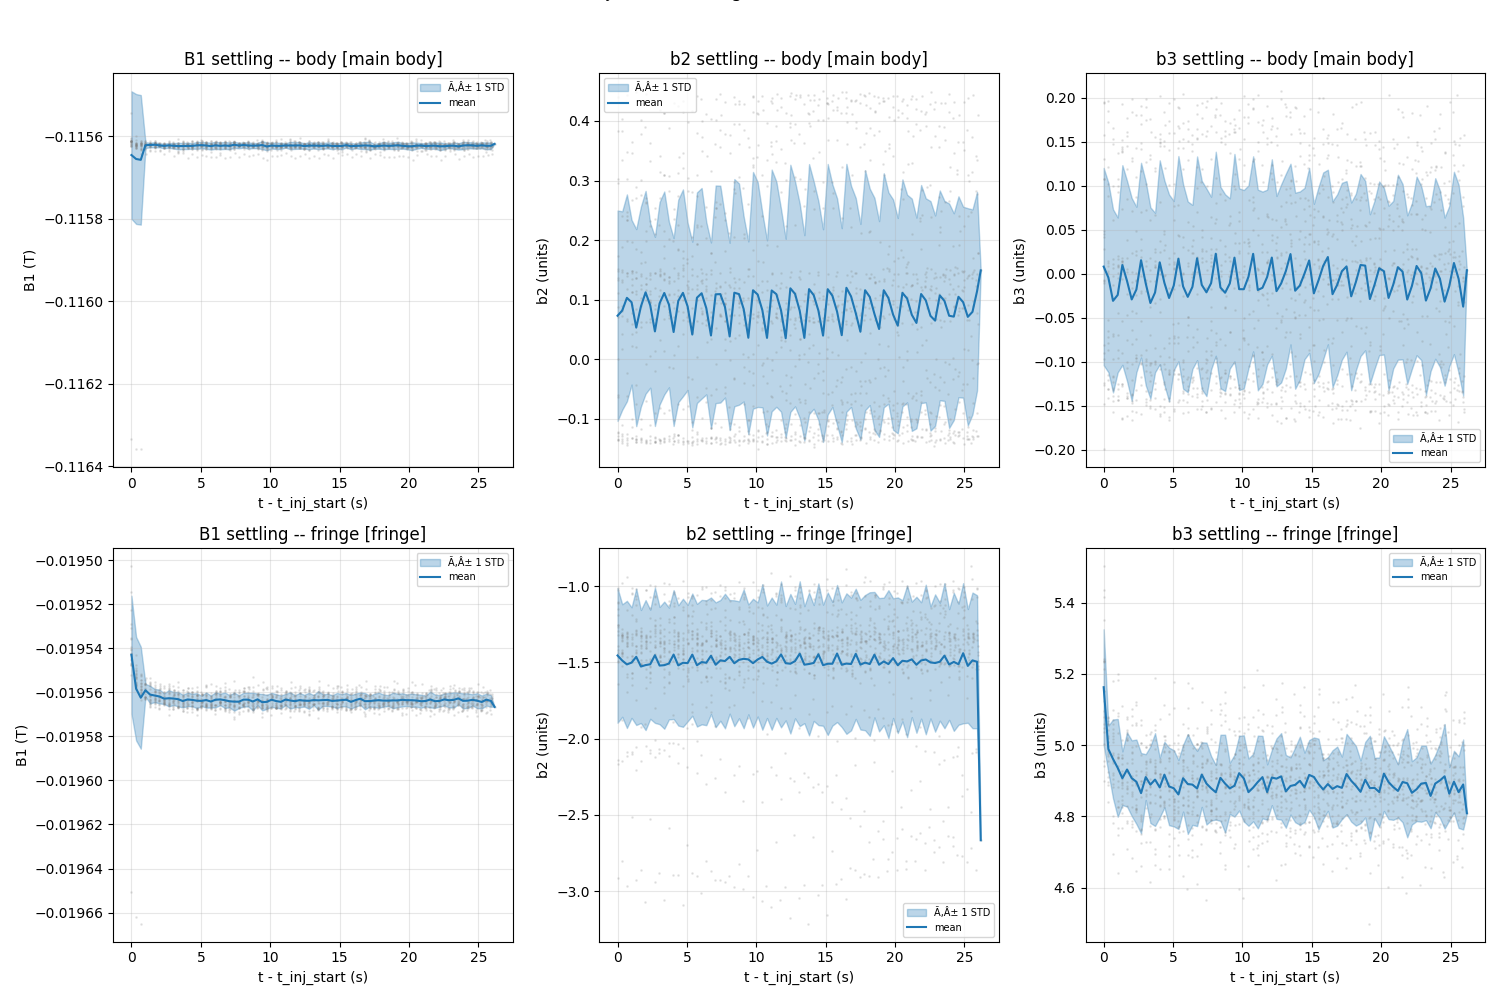

In [20]:
_eddy_cols = [("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)")]
fig, axes = plt.subplots(len(SEGMENTS), len(_eddy_cols),
                         figsize=(5 * len(_eddy_cols), 5 * len(SEGMENTS)))
if len(SEGMENTS) == 1:
    axes = axes[np.newaxis, :]

for i, seg in enumerate(SEGMENTS):
    inj = eddy_data[seg]
    for col_idx, (col, ylabel) in enumerate(_eddy_cols):
        ax = axes[i, col_idx]
        if len(inj) == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            continue
        sc_ids = sorted([s for s in inj["sc_idx"].unique() if s >= 0])
        # Align supercycles by turn index and compute mean/std
        all_turns = {}
        for sc_id in sc_ids:
            sub = inj[inj["sc_idx"] == sc_id].sort_values("turn_in_group")
            for _, row in sub.iterrows():
                tidx = int(row["turn_in_group"])
                all_turns.setdefault(tidx, {"t": [], "y": []})
                all_turns[tidx]["t"].append(row["t_since_inj_start"])
                all_turns[tidx]["y"].append(row[col])
        turn_idxs = sorted(all_turns.keys())
        t_mean = np.array([np.mean(all_turns[k]["t"]) for k in turn_idxs])
        y_mean = np.array([np.mean(all_turns[k]["y"]) for k in turn_idxs])
        y_std = np.array([np.std(all_turns[k]["y"]) for k in turn_idxs])
        # Plot individual SCs faintly
        cmap = plt.cm.tab20(np.linspace(0, 1, max(len(sc_ids), 1)))
        for k, sc_id in enumerate(sc_ids):
            sub = inj[inj["sc_idx"] == sc_id]
            ax.plot(sub["t_since_inj_start"], sub[col], ".",
                    markersize=2, alpha=0.15, color="gray")
        # Plot mean + STD band
        ax.fill_between(t_mean, y_mean - y_std, y_mean + y_std,
                         alpha=0.3, color="tab:blue", label="Ã‚Â± 1 STD")
        ax.plot(t_mean, y_mean, "-", linewidth=1.5, color="tab:blue", label="mean")
        ax.set_xlabel("t - t_inj_start (s)"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel.split()[0]} settling -- {SEG_DISPLAY[seg]}")
        ax.legend(fontsize=7)

fig.suptitle("Injection Settling -- Mean Ã‚Â± STD", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 19. Multi-Exponential Fits (B1, b2, b3)

Fit 1-, 2-, and 3-exponential eddy models per supercycle for B1, b2, and b3.
Only plateau turns (stable current) are used -- ramp artifacts are excluded.

In [21]:
from rotating_coil_analyzer.analysis.utility_functions import (
    eddy_model, double_eddy_model, triple_eddy_model,
    validate_eddy_model_selection,
)

def _compute_r2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

def _aic(n_pts, k, ss_res):
    if n_pts <= k + 1 or ss_res <= 0:
        return np.inf
    aic = n_pts * np.log(ss_res / n_pts) + 2 * k
    return aic + (2 * k * (k + 1)) / max(n_pts - k - 1, 1)

def _fit_123(t, y):
    """Fit 1/2/3-tau models. Returns dict {1: ..., 2: ..., 3: ...}."""
    fr = {}
    n = len(t)
    if n < MIN_INJECTION_TURNS:
        return None
    y_inf = y[-max(5, n // 4):].mean()
    A0 = y[0] - y_inf
    tau0 = max(t[-1] / 3, 0.5)

    # 1-tau
    try:
        p1, _ = curve_fit(eddy_model, t, y, p0=[y_inf, A0, tau0],
                          bounds=([-np.inf, -np.inf, 0.05], [np.inf, np.inf, 1000]), maxfev=10000)
        pred = eddy_model(t, *p1)
        r2 = _compute_r2(y, pred); ss = np.sum((y - pred)**2)
        fr[1] = {"popt": p1, "r2": r2, "aic": _aic(n, 3, ss)}
    except (RuntimeError, ValueError):
        fr[1] = {"popt": None, "r2": 0, "aic": np.inf}

    # 2-tau
    if n >= 10 and fr[1].get("popt") is not None:
        try:
            Bi, Ai, ti = fr[1]["popt"]
            p2, _ = curve_fit(double_eddy_model, t, y,
                              p0=[Bi, Ai*0.5, ti/3, Ai*0.5, ti*2],
                              bounds=([-np.inf,-np.inf,0.05,-np.inf,0.05],
                                      [np.inf,np.inf,500,np.inf,2000]), maxfev=20000)
            if p2[2] > p2[4]:
                p2 = np.array([p2[0], p2[3], p2[4], p2[1], p2[2]])
            pred = double_eddy_model(t, *p2)
            r2 = _compute_r2(y, pred); ss = np.sum((y - pred)**2)
            fr[2] = {"popt": p2, "r2": r2, "aic": _aic(n, 5, ss)}
        except (RuntimeError, ValueError):
            fr[2] = {"popt": None, "r2": 0, "aic": np.inf}
    else:
        fr[2] = {"popt": None, "r2": 0, "aic": np.inf}

    # 3-tau
    if n >= 20 and fr.get(2, {}).get("popt") is not None:
        try:
            B2, A12, t12, A22, t22 = fr[2]["popt"]
            p3, _ = curve_fit(triple_eddy_model, t, y,
                              p0=[B2, A12*0.5, t12/2, A12*0.5, t12*2, A22, t22*2],
                              bounds=([-np.inf,-np.inf,0.05,-np.inf,0.05,-np.inf,0.05],
                                      [np.inf,np.inf,500,np.inf,2000,np.inf,5000]), maxfev=30000)
            taus = [(p3[1],p3[2]), (p3[3],p3[4]), (p3[5],p3[6])]
            taus.sort(key=lambda x: x[1])
            p3 = np.array([p3[0], taus[0][0], taus[0][1], taus[1][0], taus[1][1], taus[2][0], taus[2][1]])
            pred = triple_eddy_model(t, *p3)
            r2 = _compute_r2(y, pred)
            if r2 < 0:
                fr[3] = {"popt": None, "r2": 0, "aic": np.inf}
            else:
                ss = np.sum((y - pred)**2)
                fr[3] = {"popt": p3, "r2": r2, "aic": _aic(n, 7, ss)}
        except (RuntimeError, ValueError):
            fr[3] = {"popt": None, "r2": 0, "aic": np.inf}
    else:
        fr[3] = {"popt": None, "r2": 0, "aic": np.inf}
    return fr

def _print_fit_detail(seg_disp, qlabel, fr, best_ntau):
    for ntau in [1, 2, 3]:
        r = fr.get(ntau, {"r2": 0, "popt": None})
        tag = " <-- BEST" if ntau == best_ntau and r["popt"] is not None and r["r2"] > 0 else ""
        if r["popt"] is not None and r["r2"] > 0:
            p = r["popt"]
            if ntau == 1:
                s = f"tau={p[2]:.3f} s, A={p[1]:.6f}, B_inf={p[0]:.6f}"
            elif ntau == 2:
                s = f"tau1={p[2]:.3f} s, tau2={p[4]:.3f} s, A1={p[1]:.6f}, A2={p[3]:.6f}, B_inf={p[0]:.6f}"
            else:
                s = f"tau1={p[2]:.3f} s, tau2={p[4]:.3f} s, tau3={p[6]:.3f} s, B_inf={p[0]:.6f}"
            print(f"  {seg_disp} {qlabel}: {ntau}-tau R2={r['r2']:.4f}  {s}{tag}")
        else:
            print(f"  {seg_disp} {qlabel}: {ntau}-tau FAILED")

def _print_summary_table(title, results_dict, segments, quantities):
    print(f"\n{title}")
    print("=" * 120)
    print(f"{'Segment':<20s} {'Quantity':<14s} {'Model':>6s} {'R2':>8s} "
          f"{'B_inf':>12s} {'A / A1':>12s} {'tau1 (s)':>10s} {'A2':>12s} {'tau2 (s)':>10s} {'tau3 (s)':>10s}")
    print("-" * 120)
    for seg in segments:
        for col, qlabel in quantities:
            res = results_dict[seg][col]
            bn = res.get("best_ntau")
            bp = res.get("best_popt")
            br = res.get("best_r2", 0)
            if bp is None or br <= 0:
                print(f"{SEG_DISPLAY[seg]:<20s} {qlabel:<14s} {'--':>6s} {'--':>8s}")
                continue
            if bn == 1:
                print(f"{SEG_DISPLAY[seg]:<20s} {qlabel:<14s} {'1-tau':>6s} {br:8.4f} "
                      f"{bp[0]:12.6f} {bp[1]:12.6f} {bp[2]:10.3f}")
            elif bn == 2:
                print(f"{SEG_DISPLAY[seg]:<20s} {qlabel:<14s} {'2-tau':>6s} {br:8.4f} "
                      f"{bp[0]:12.6f} {bp[1]:12.6f} {bp[2]:10.3f} {bp[3]:12.6f} {bp[4]:10.3f}")
            elif bn == 3:
                print(f"{SEG_DISPLAY[seg]:<20s} {qlabel:<14s} {'3-tau':>6s} {br:8.4f} "
                      f"{bp[0]:12.6f} {bp[1]:12.6f} {bp[2]:10.3f} {bp[3]:12.6f} {bp[4]:10.3f} {bp[6]:10.3f}")
    print("=" * 120)

# ---- Fit on MEAN across supercycles (all turns, no outlier removal) ----
EDDY_QUANTITIES = [("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)")]

eddy_fit_all = {}
for seg in SEGMENTS:
    eddy_fit_all[seg] = {}
    inj = eddy_data[seg]
    if len(inj) == 0:
        for col, _ in EDDY_QUANTITIES:
            eddy_fit_all[seg][col] = {"best_ntau": None, "best_popt": None, "best_r2": 0,
                                       "fit_results": {}, "mean_t": None, "mean_y": None, "std_y": None}
        continue

    sc_ids = sorted([s for s in inj["sc_idx"].unique() if s >= 0])
    print(f"{SEG_DISPLAY[seg]}: {len(sc_ids)} supercycles")

    for col, qlabel in EDDY_QUANTITIES:
        # Build mean per turn index
        all_turns = {}
        for sc_id in sc_ids:
            sub = inj[inj["sc_idx"] == sc_id].sort_values("turn_in_group")
            for _, row in sub.iterrows():
                tidx = int(row["turn_in_group"])
                all_turns.setdefault(tidx, {"t": [], "y": []})
                all_turns[tidx]["t"].append(row["t_since_inj_start"])
                all_turns[tidx]["y"].append(row[col])
        turn_idxs = sorted(all_turns.keys())
        t_mean = np.array([np.mean(all_turns[k]["t"]) for k in turn_idxs])
        y_mean = np.array([np.mean(all_turns[k]["y"]) for k in turn_idxs])
        y_std = np.array([np.std(all_turns[k]["y"]) for k in turn_idxs])

        # Fit on full mean (no outlier removal)
        best_ntau, best_popt, best_r2 = 1, None, 0.0
        fr = _fit_123(t_mean, y_mean)
        if fr is not None:
            best_ntau, _ = validate_eddy_model_selection(fr)
            if best_ntau in fr and fr[best_ntau].get("popt") is not None:
                best_popt = fr[best_ntau]["popt"]
                best_r2 = fr[best_ntau]["r2"]
            _print_fit_detail(SEG_DISPLAY[seg], qlabel, fr, best_ntau)
        else:
            fr = {}

        eddy_fit_all[seg][col] = {
            "best_ntau": best_ntau, "best_popt": best_popt, "best_r2": best_r2,
            "fit_results": fr, "mean_t": t_mean, "mean_y": y_mean, "std_y": y_std,
        }

_print_summary_table("BEFORE OUTLIER REMOVAL (fit on mean across SCs, all turns)",
                     eddy_fit_all, SEGMENTS, EDDY_QUANTITIES)

body [main body]: 21 supercycles
  body [main body] B1 (T): 1-tau R2=0.6651  tau=0.867 s, A=-0.000032, B_inf=-0.115623 <-- BEST
  body [main body] B1 (T): 2-tau R2=0.6819  tau1=1.289 s, tau2=2.202 s, A1=-0.000059, A2=0.000027, B_inf=-0.115623
  body [main body] B1 (T): 3-tau R2=0.6831  tau1=1.381 s, tau2=3.399 s, tau3=4.065 s, B_inf=-0.115623
  body [main body] b2 (units): 1-tau R2=0.0062  tau=1000.000 s, A=-0.276726, B_inf=0.360128 <-- BEST
  body [main body] b2 (units): 2-tau R2=0.0114  tau1=499.999 s, tau2=1999.984 s, A1=24.704877, A2=-97.450892, B_inf=72.833530
  body [main body] b2 (units): 3-tau R2=0.0114  tau1=395.876 s, tau2=791.632 s, tau3=3594.083 s, B_inf=168.469216
  body [main body] b3 (units): 1-tau R2=0.0076  tau=4.881 s, A=-0.005534, B_inf=-0.006189 <-- BEST
  body [main body] b3 (units): 2-tau R2=0.0365  tau1=0.245 s, tau2=2.667 s, A1=0.030213, A2=-0.015007, B_inf=-0.006146
  body [main body] b3 (units): 3-tau R2=0.0372  tau1=0.370 s, tau2=0.400 s, tau3=3.099 s, B_inf=

  fringe [fringe] B1 (T): 1-tau R2=0.8988  tau=0.291 s, A=0.000020, B_inf=-0.019564
  fringe [fringe] B1 (T): 2-tau R2=0.9468  tau1=0.145 s, tau2=2.003 s, A1=0.000016, A2=0.000004, B_inf=-0.019564 <-- BEST
  fringe [fringe] B1 (T): 3-tau R2=0.9396  tau1=0.124 s, tau2=0.293 s, tau3=3.409 s, B_inf=-0.019564
  fringe [fringe] b2 (units): 1-tau R2=0.0358  tau=1000.000 s, A=3.332603, B_inf=-4.796049 <-- BEST
  fringe [fringe] b2 (units): 2-tau R2=0.0949  tau1=499.999 s, tau2=2000.000 s, A1=-419.977487, A2=1653.932802, B_inf=-1235.488642
  fringe [fringe] b2 (units): 3-tau R2=0.0951  tau1=500.000 s, tau2=674.990 s, tau3=3244.381 s, B_inf=-2600.914510
  fringe [fringe] b3 (units): 1-tau R2=0.7599  tau=0.483 s, A=0.262500, B_inf=4.889634
  fringe [fringe] b3 (units): 2-tau R2=0.7772  tau1=0.050 s, tau2=0.907 s, A1=0.127449, A2=0.146732, B_inf=4.888651 <-- BEST
  fringe [fringe] b3 (units): 3-tau FAILED

BEFORE OUTLIER REMOVAL (fit on mean across SCs, all turns)
Segment              Quantity   

### Multi-Tau Fit Comparison Plots

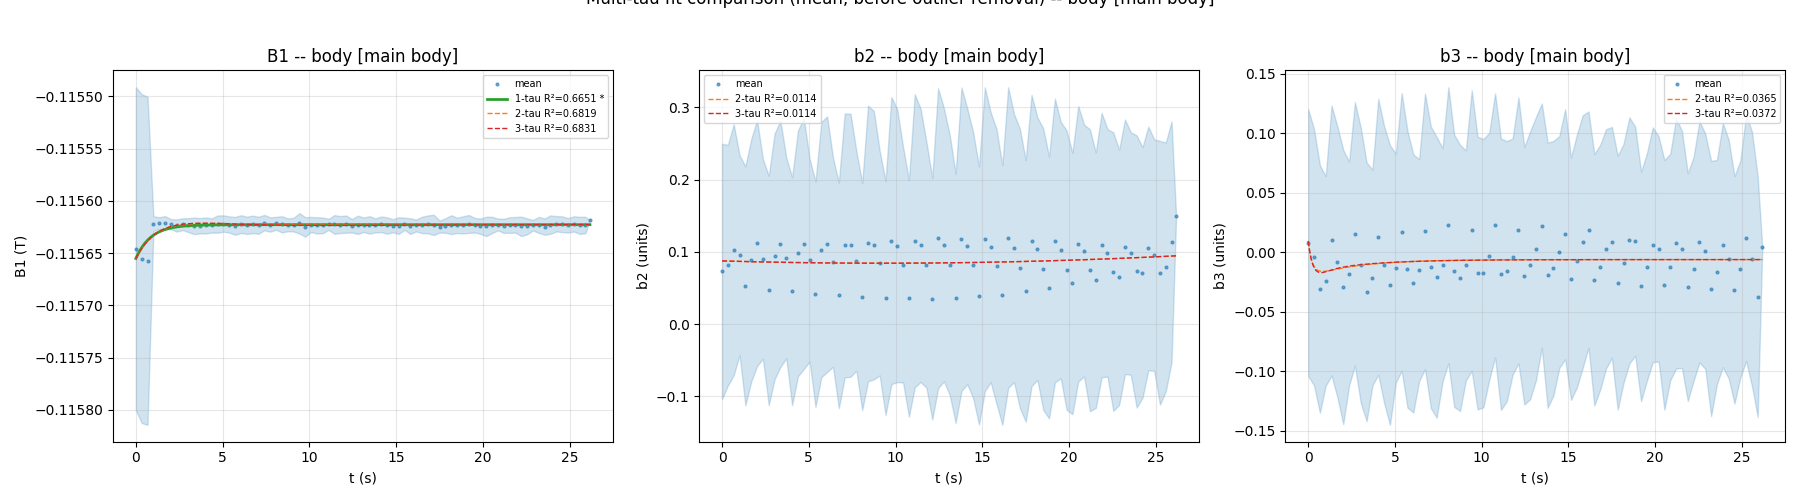

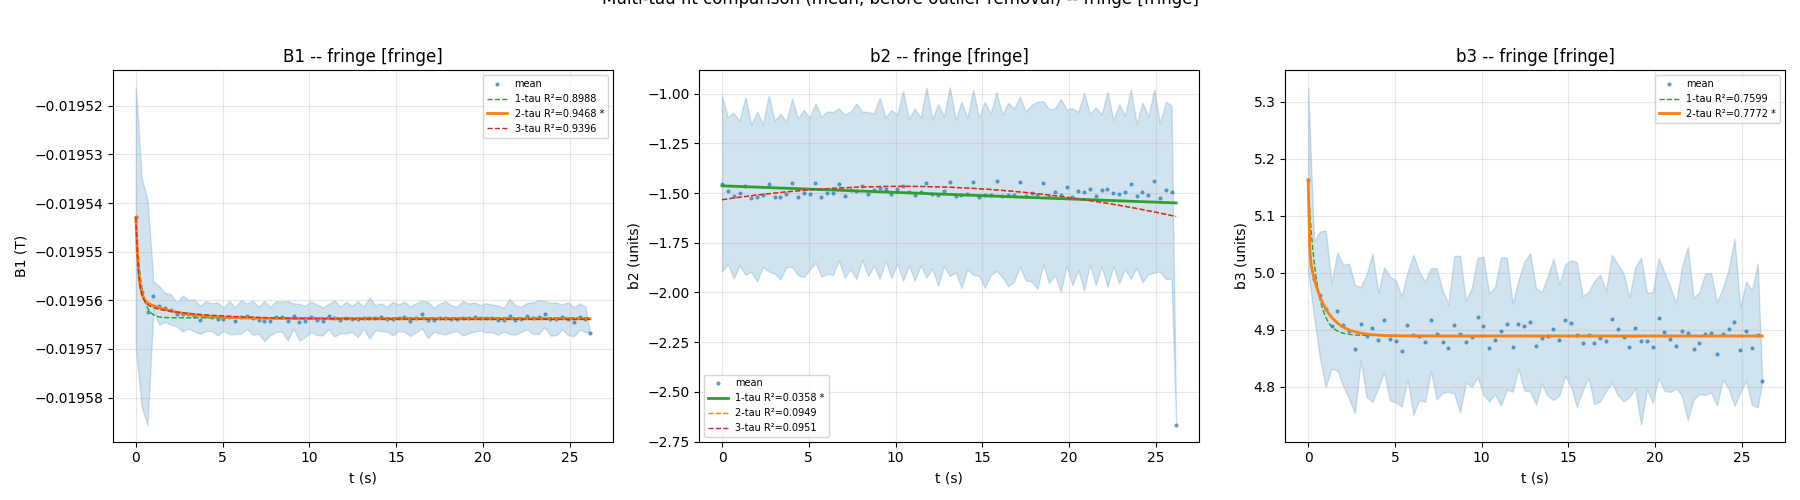

In [22]:
# Plot 1/2/3-tau fits on the mean for all segments
_models_t = {1: eddy_model, 2: double_eddy_model, 3: triple_eddy_model}
_colors_t = {1: "tab:green", 2: "tab:orange", 3: "tab:red"}
_labels_t = {1: "1-tau", 2: "2-tau", 3: "3-tau"}

for seg in SEGMENTS:
    fig, axes = plt.subplots(1, len(EDDY_QUANTITIES), figsize=(6 * len(EDDY_QUANTITIES), 5))
    if len(EDDY_QUANTITIES) == 1:
        axes = [axes]

    for ax, (col, qlabel) in zip(axes, EDDY_QUANTITIES):
        res = eddy_fit_all[seg][col]
        tm = res.get("mean_t")
        ym = res.get("mean_y")
        ys = res.get("std_y")
        if tm is None or len(tm) == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            continue

        # Mean Ã‚Â± STD
        ax.fill_between(tm, ym - ys, ym + ys, alpha=0.2, color="tab:blue")
        ax.plot(tm, ym, ".", markersize=4, color="tab:blue", alpha=0.6, label="mean")

        # Overlay all converged fits
        fr = res.get("fit_results", {})
        if fr:
            t_fine = np.linspace(tm.min(), tm.max(), 300)
            for ntau in [1, 2, 3]:
                r = fr.get(ntau, {"popt": None, "r2": 0})
                if r["popt"] is not None and r["r2"] > 0.01:
                    is_best = res["best_ntau"] == ntau
                    ax.plot(t_fine, _models_t[ntau](t_fine, *r["popt"]),
                            color=_colors_t[ntau], linewidth=2 if is_best else 1,
                            linestyle="-" if is_best else "--",
                            label=f"{_labels_t[ntau]} R\u00b2={r['r2']:.4f}" + (" *" if is_best else ""))
        ax.legend(fontsize=7); ax.set_xlabel("t (s)"); ax.set_ylabel(qlabel)
        ax.set_title(f"{qlabel.split()[0]} -- {SEG_DISPLAY[seg]}")

    fig.suptitle(f"Multi-tau fit comparison (mean, before outlier removal) -- {SEG_DISPLAY[seg]}", fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

---
## 20. Outlier-Cleaned Fits (Mean Ã‚Â± STD)

Remove ramp artifacts using residual-based clipping:
1. Compute mean across supercycles per turn index
2. Fit a preliminary 1-tau model to the mean
3. Remove turns whose residuals exceed 3.5Ãƒâ€” MAD of residuals
4. Refit 1/2/3-tau models on the cleaned mean and select best by AICc

body [main body] B1 (T): removed 8/79 outlier turns
  body [main body] B1 (T): 1-tau R2=0.0289  tau=198.183 s, A=0.000004, B_inf=-0.115627 <-- BEST  [all higher models unphysical]
  body [main body] B1 (T): 2-tau R2=0.0290  tau1=69.305 s, tau2=393.704 s, A1=-0.000002, A2=0.000016, B_inf=-0.115637
  body [main body] B1 (T): 3-tau R2=0.0693  tau1=34.653 s, tau2=138.611 s, tau3=787.409 s, B_inf=-0.110157
  body [main body] b2 (units): 1-tau R2=0.0062  tau=1000.000 s, A=-0.276726, B_inf=0.360128 <-- BEST  [all higher models unphysical]
  body [main body] b2 (units): 2-tau R2=0.0114  tau1=499.999 s, tau2=1999.984 s, A1=24.704877, A2=-97.450892, B_inf=72.833530
  body [main body] b2 (units): 3-tau R2=0.0114  tau1=395.876 s, tau2=791.632 s, tau3=3594.083 s, B_inf=168.469216
  body [main body] b3 (units): 1-tau R2=0.0076  tau=4.881 s, A=-0.005534, B_inf=-0.006189 <-- BEST
  body [main body] b3 (units): 2-tau R2=0.0365  tau1=0.245 s, tau2=2.667 s, A1=0.030213, A2=-0.015007, B_inf=-0.006146
  bo

fringe [fringe] b2 (units): removed 1/79 outlier turns
  fringe [fringe] b2 (units): 1-tau R2=0.0003  tau=5.198 s, A=-0.001644, B_inf=-1.491613 <-- BEST
  fringe [fringe] b2 (units): 2-tau R2=0.0467  tau1=0.344 s, tau2=1.979 s, A1=0.063257, A2=-0.026469, B_inf=-1.491076
  fringe [fringe] b2 (units): 3-tau R2=0.0482  tau1=0.169 s, tau2=1.181 s, tau3=1.291 s, B_inf=-1.490987
fringe [fringe] b3 (units): removed 1/79 outlier turns
  fringe [fringe] b3 (units): 1-tau R2=0.8034  tau=0.474 s, A=0.261959, B_inf=4.890767
  fringe [fringe] b3 (units): 2-tau R2=0.8205  tau1=0.050 s, tau2=0.870 s, A1=0.124919, A2=0.148064, B_inf=4.889848 <-- BEST
  fringe [fringe] b3 (units): 3-tau FAILED

Segment              Quantity        Model       R2        B_inf       A / A1   tau1 (s)           A2   tau2 (s)   tau3 (s)
------------------------------------------------------------------------------------------------------------------------
body [main body]     B1 (T)          1-tau   0.0289    -0.115627    

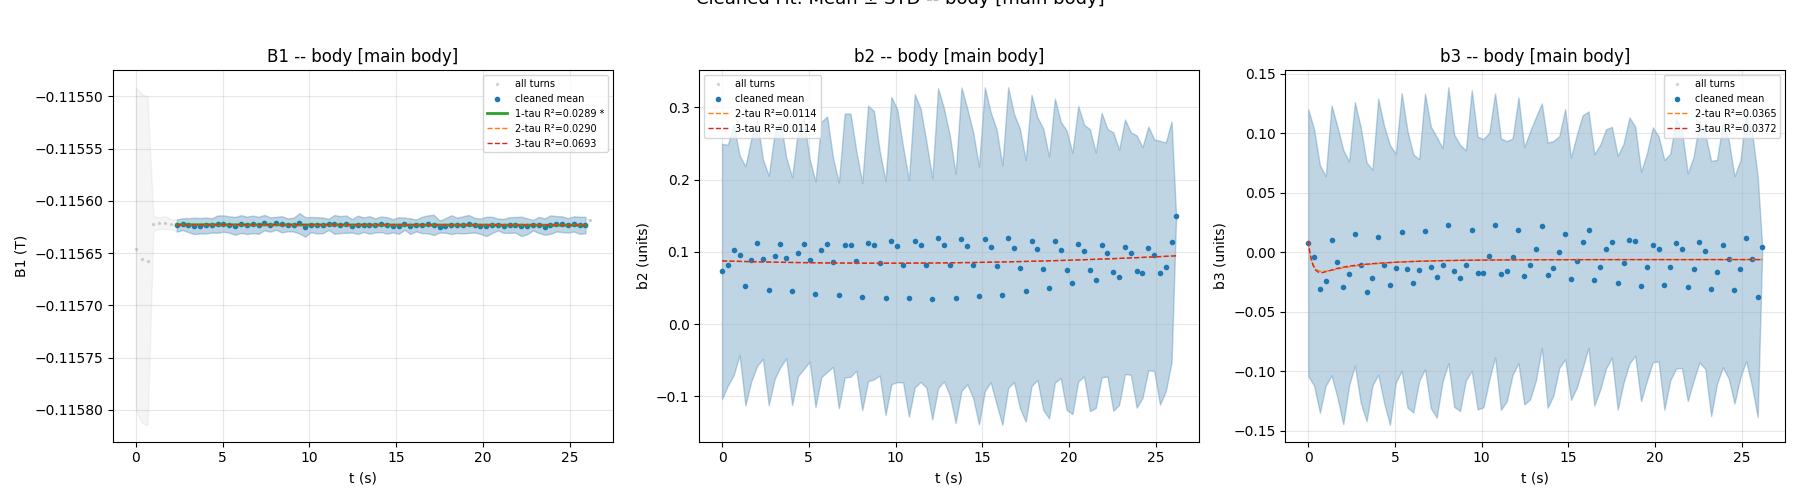

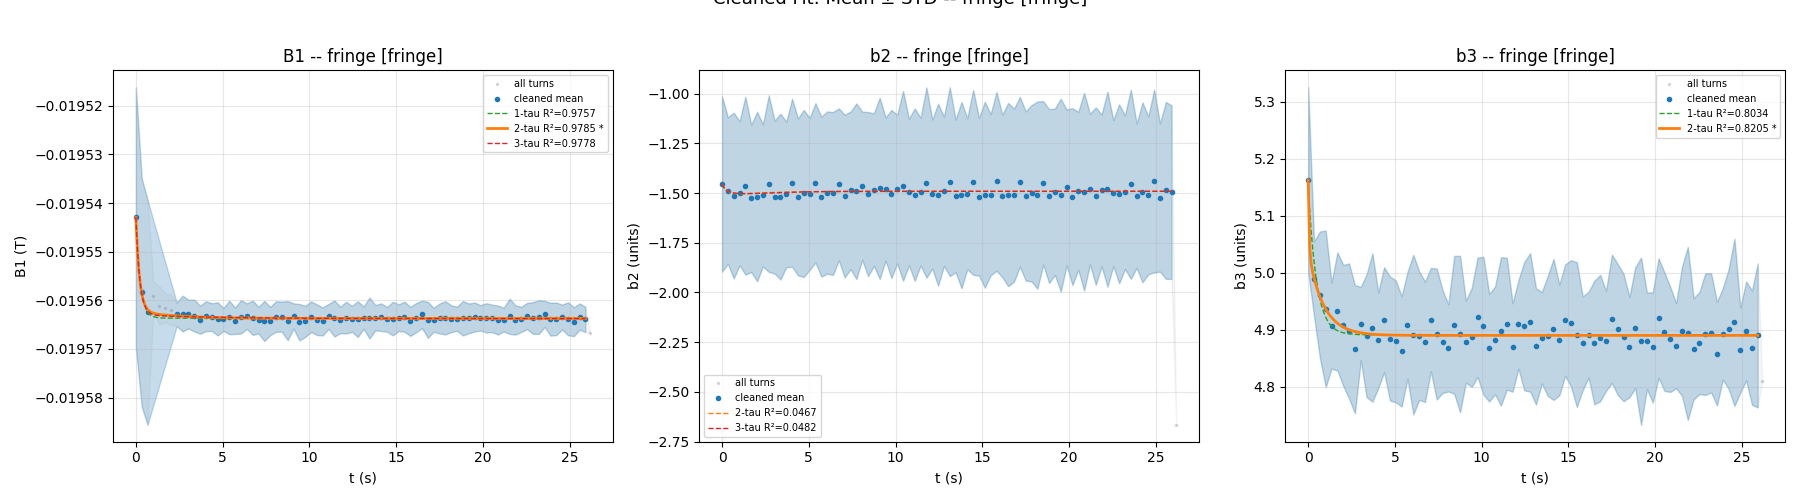


AFTER OUTLIER REMOVAL (fit on mean, ramp artifacts removed)
Segment              Quantity        Model       R2        B_inf       A / A1   tau1 (s)           A2   tau2 (s)   tau3 (s)
------------------------------------------------------------------------------------------------------------------------
body [main body]     B1 (T)          1-tau   0.0289    -0.115627     0.000004    198.183
body [main body]     b2 (units)      1-tau   0.0062     0.360128    -0.276726   1000.000
body [main body]     b3 (units)      1-tau   0.0076    -0.006189    -0.005534      4.881
fringe [fringe]      B1 (T)          2-tau   0.9785    -0.019564     0.000019      0.210     0.000001      2.405
fringe [fringe]      b2 (units)      1-tau   0.0003    -1.491613    -0.001644      5.198
fringe [fringe]      b3 (units)      2-tau   0.8205     4.889848     0.124919      0.050     0.148064      0.870


In [23]:
# --- Outlier removal (residual-based) and clean refit ---
from rotating_coil_analyzer.analysis.utility_functions import (
    eddy_model, double_eddy_model, triple_eddy_model,
    validate_eddy_model_selection,
)

def _compute_r2_c(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

def _aic_c(n_pts, k, ss_res):
    if n_pts <= k + 1 or ss_res <= 0:
        return np.inf
    aic = n_pts * np.log(ss_res / n_pts) + 2 * k
    return aic + (2 * k * (k + 1)) / max(n_pts - k - 1, 1)

def _residual_clip(t, y, threshold=3.5):
    """Remove outliers based on residuals from a preliminary 1-tau fit.

    Unlike raw MAD, this preserves the real exponential signal and only
    removes points that deviate from the expected trend (ramp artifacts).
    """
    if len(t) < 5:
        return np.ones(len(t), dtype=bool)
    # Preliminary fit
    try:
        y_inf_est = y[-max(3, len(y) // 4):].mean()
        A_est = y[0] - y_inf_est
        tau_est = max(t[-1] / 3, 0.5)
        popt, _ = curve_fit(eddy_model, t, y, p0=[y_inf_est, A_est, tau_est],
                             bounds=([-np.inf, -np.inf, 0.05], [np.inf, np.inf, 1000]),
                             maxfev=5000)
        residuals = y - eddy_model(t, *popt)
    except (RuntimeError, ValueError):
        # If preliminary fit fails, fall back to simple differences
        residuals = np.diff(y, prepend=y[0])

    med_r = np.median(residuals)
    mad_r = np.median(np.abs(residuals - med_r))
    if mad_r < 1e-15:
        return np.ones(len(t), dtype=bool)
    modified_z = 0.6745 * np.abs(residuals - med_r) / mad_r
    return modified_z < threshold

_models_c = {1: eddy_model, 2: double_eddy_model, 3: triple_eddy_model}
_colors_c = {1: "tab:green", 2: "tab:orange", 3: "tab:red"}
_labels_c = {1: "1-tau", 2: "2-tau", 3: "3-tau"}
EDDY_QUANTITIES_C = [("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)")]

eddy_clean_results = {}
for seg in SEGMENTS:
    eddy_clean_results[seg] = {}
    inj = eddy_data[seg]
    if len(inj) == 0:
        for col, _ in EDDY_QUANTITIES_C:
            eddy_clean_results[seg][col] = {"mean_t": None}
        continue

    sc_ids = sorted([s for s in inj["sc_idx"].unique() if s >= 0])

    for col, qlabel in EDDY_QUANTITIES_C:
        # Build per-turn arrays across SCs (aligned by turn_in_group)
        all_turns = {}
        for sc_id in sc_ids:
            sub = inj[inj["sc_idx"] == sc_id].sort_values("turn_in_group")
            for _, row in sub.iterrows():
                tidx = int(row["turn_in_group"])
                all_turns.setdefault(tidx, {"t": [], "y": []})
                all_turns[tidx]["t"].append(row["t_since_inj_start"])
                all_turns[tidx]["y"].append(row[col])

        turn_idxs = sorted(all_turns.keys())
        t_mean = np.array([np.mean(all_turns[k]["t"]) for k in turn_idxs])
        y_mean = np.array([np.mean(all_turns[k]["y"]) for k in turn_idxs])
        y_std = np.array([np.std(all_turns[k]["y"]) for k in turn_idxs])

        # Residual-based clipping (preserves exponential trend, removes ramp artifacts)
        ok = _residual_clip(t_mean, y_mean, threshold=3.5)
        tc, yc, ysc = t_mean[ok], y_mean[ok], y_std[ok]

        n_removed = int((~ok).sum())
        if n_removed > 0:
            print(f"{SEG_DISPLAY[seg]} {qlabel}: removed {n_removed}/{len(t_mean)} outlier turns")

        # Fit 1/2/3-tau on the cleaned mean
        best_ntau, best_popt, best_r2 = 1, None, 0.0
        fit_results_c = {}
        if len(tc) >= MIN_INJECTION_TURNS:
            y_inf_est = yc[-max(5, len(yc) // 4):].mean()
            A_est = yc[0] - y_inf_est
            tau_est = max(tc[-1] / 3, 0.5)

            # 1-tau
            try:
                popt1, _ = curve_fit(eddy_model, tc, yc, p0=[y_inf_est, A_est, tau_est],
                                     bounds=([-np.inf, -np.inf, 0.05], [np.inf, np.inf, 1000]),
                                     maxfev=10000)
                pred = eddy_model(tc, *popt1)
                r2 = _compute_r2_c(yc, pred)
                ss = np.sum((yc - pred) ** 2)
                fit_results_c[1] = {"popt": popt1, "r2": r2, "aic": _aic_c(len(tc), 3, ss)}
            except (RuntimeError, ValueError):
                fit_results_c[1] = {"popt": None, "r2": 0, "aic": np.inf}

            # 2-tau
            if len(tc) >= 10 and fit_results_c[1].get("popt") is not None:
                try:
                    Bi, Ai, ti = fit_results_c[1]["popt"]
                    popt2, _ = curve_fit(double_eddy_model, tc, yc,
                                         p0=[Bi, Ai * 0.5, ti / 3, Ai * 0.5, ti * 2],
                                         bounds=([-np.inf, -np.inf, 0.05, -np.inf, 0.05],
                                                 [np.inf, np.inf, 500, np.inf, 2000]),
                                         maxfev=20000)
                    if popt2[2] > popt2[4]:
                        popt2 = np.array([popt2[0], popt2[3], popt2[4], popt2[1], popt2[2]])
                    pred = double_eddy_model(tc, *popt2)
                    r2 = _compute_r2_c(yc, pred)
                    ss = np.sum((yc - pred) ** 2)
                    fit_results_c[2] = {"popt": popt2, "r2": r2, "aic": _aic_c(len(tc), 5, ss)}
                except (RuntimeError, ValueError):
                    fit_results_c[2] = {"popt": None, "r2": 0, "aic": np.inf}
            else:
                fit_results_c[2] = {"popt": None, "r2": 0, "aic": np.inf}

            # 3-tau
            if len(tc) >= 20 and fit_results_c.get(2, {}).get("popt") is not None:
                try:
                    B2, A12, t12, A22, t22 = fit_results_c[2]["popt"]
                    popt3, _ = curve_fit(triple_eddy_model, tc, yc,
                                         p0=[B2, A12*0.5, t12/2, A12*0.5, t12*2, A22, t22*2],
                                         bounds=([-np.inf, -np.inf, 0.05, -np.inf, 0.05, -np.inf, 0.05],
                                                 [np.inf, np.inf, 500, np.inf, 2000, np.inf, 5000]),
                                         maxfev=30000)
                    taus = [(popt3[1], popt3[2]), (popt3[3], popt3[4]), (popt3[5], popt3[6])]
                    taus.sort(key=lambda x: x[1])
                    popt3 = np.array([popt3[0], taus[0][0], taus[0][1],
                                      taus[1][0], taus[1][1], taus[2][0], taus[2][1]])
                    pred = triple_eddy_model(tc, *popt3)
                    r2 = _compute_r2_c(yc, pred)
                    if r2 < 0:  # Divergent fit
                        fit_results_c[3] = {"popt": None, "r2": 0, "aic": np.inf}
                    else:
                        ss = np.sum((yc - pred) ** 2)
                        fit_results_c[3] = {"popt": popt3, "r2": r2, "aic": _aic_c(len(tc), 7, ss)}
                except (RuntimeError, ValueError):
                    fit_results_c[3] = {"popt": None, "r2": 0, "aic": np.inf}
            else:
                fit_results_c[3] = {"popt": None, "r2": 0, "aic": np.inf}

            # Select best model with overfitting guard
            best_ntau, selection_reason = validate_eddy_model_selection(fit_results_c)
            if best_ntau in fit_results_c and fit_results_c[best_ntau].get("popt") is not None:
                best_popt = fit_results_c[best_ntau]["popt"]
                best_r2 = fit_results_c[best_ntau]["r2"]

            reason_tag = f"  [{selection_reason}]" if selection_reason != "OK" else ""
            for ntau in [1, 2, 3]:
                r = fit_results_c.get(ntau, {"r2": 0, "popt": None})
                tag = f" <-- BEST{reason_tag}" if ntau == best_ntau and r["popt"] is not None and r["r2"] > 0 else ""
                if r["popt"] is not None and r["r2"] > 0:
                    popt = r["popt"]
                    if ntau == 1:
                        tau_str = f"tau={popt[2]:.3f} s, A={popt[1]:.6f}, B_inf={popt[0]:.6f}"
                    elif ntau == 2:
                        tau_str = (f"tau1={popt[2]:.3f} s, tau2={popt[4]:.3f} s, "
                                   f"A1={popt[1]:.6f}, A2={popt[3]:.6f}, B_inf={popt[0]:.6f}")
                    else:
                        tau_str = (f"tau1={popt[2]:.3f} s, tau2={popt[4]:.3f} s, tau3={popt[6]:.3f} s, "
                                   f"B_inf={popt[0]:.6f}")
                    print(f"  {SEG_DISPLAY[seg]} {qlabel}: {ntau}-tau R2={r['r2']:.4f}  {tau_str}{tag}")
                else:
                    print(f"  {SEG_DISPLAY[seg]} {qlabel}: {ntau}-tau FAILED")

        eddy_clean_results[seg][col] = {
            "mean_t": tc, "mean_y": yc, "std_y": ysc,
            "full_t": t_mean, "full_y": y_mean, "full_std": y_std,
            "best_ntau": best_ntau, "best_popt": best_popt, "best_r2": best_r2,
            "fit_results": fit_results_c,
        }

# --- Summary table with tau values ---
print("\n" + "=" * 120)
print(f"{'Segment':<20s} {'Quantity':<14s} {'Model':>6s} {'R2':>8s} "
      f"{'B_inf':>12s} {'A / A1':>12s} {'tau1 (s)':>10s} {'A2':>12s} {'tau2 (s)':>10s} {'tau3 (s)':>10s}")
print("-" * 120)
for seg in SEGMENTS:
    for col, qlabel in EDDY_QUANTITIES_C:
        res = eddy_clean_results[seg][col]
        bn = res.get("best_ntau")
        bp = res.get("best_popt")
        br = res.get("best_r2", 0)
        if bp is None or br <= 0:
            print(f"{SEG_DISPLAY[seg]:<20s} {qlabel:<14s} {'--':>6s} {'--':>8s}")
            continue
        if bn == 1:
            print(f"{SEG_DISPLAY[seg]:<20s} {qlabel:<14s} {'1-tau':>6s} {br:8.4f} "
                  f"{bp[0]:12.6f} {bp[1]:12.6f} {bp[2]:10.3f}")
        elif bn == 2:
            print(f"{SEG_DISPLAY[seg]:<20s} {qlabel:<14s} {'2-tau':>6s} {br:8.4f} "
                  f"{bp[0]:12.6f} {bp[1]:12.6f} {bp[2]:10.3f} {bp[3]:12.6f} {bp[4]:10.3f}")
        elif bn == 3:
            print(f"{SEG_DISPLAY[seg]:<20s} {qlabel:<14s} {'3-tau':>6s} {br:8.4f} "
                  f"{bp[0]:12.6f} {bp[1]:12.6f} {bp[2]:10.3f} {bp[3]:12.6f} {bp[4]:10.3f} {bp[6]:10.3f}")
print("=" * 120)
for seg in SEGMENTS:
    fig, axes = plt.subplots(1, len(EDDY_QUANTITIES_C), figsize=(6 * len(EDDY_QUANTITIES_C), 5))
    if len(EDDY_QUANTITIES_C) == 1:
        axes = [axes]

    for ax, (col, qlabel) in zip(axes, EDDY_QUANTITIES_C):
        res = eddy_clean_results[seg][col]
        if res.get("mean_t") is None or len(res.get("mean_t", [])) == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            continue

        ft, fy, fs = res["full_t"], res["full_y"], res["full_std"]
        tc, yc, ysc = res["mean_t"], res["mean_y"], res["std_y"]

        # Full data (gray, with outliers)
        ax.fill_between(ft, fy - fs, fy + fs, alpha=0.08, color="gray")
        ax.plot(ft, fy, ".", markersize=3, alpha=0.25, color="gray", label="all turns")

        # Cleaned mean Ã‚Â± STD
        ax.fill_between(tc, yc - ysc, yc + ysc, alpha=0.25, color="tab:blue")
        ax.plot(tc, yc, "o", markersize=3, color="tab:blue", label="cleaned mean")

        # Fit curves
        fr = res.get("fit_results", {})
        if fr:
            t_fine = np.linspace(tc.min(), tc.max(), 300)
            for ntau in [1, 2, 3]:
                r = fr.get(ntau, {"popt": None, "r2": 0})
                if r["popt"] is not None and r["r2"] > 0.01:
                    is_best = res["best_ntau"] == ntau
                    ax.plot(t_fine, _models_c[ntau](t_fine, *r["popt"]),
                            color=_colors_c[ntau], linewidth=2.0 if is_best else 1.0,
                            linestyle="-" if is_best else "--",
                            label=f"{_labels_c[ntau]} R\u00b2={r['r2']:.4f}" + (" *" if is_best else ""))

        ax.set_xlabel("t (s)"); ax.set_ylabel(qlabel)
        ax.set_title(f"{qlabel.split()[0]} -- {SEG_DISPLAY[seg]}")
        ax.legend(fontsize=7)

    fig.suptitle(f"Cleaned Fit: Mean \u00b1 STD -- {SEG_DISPLAY[seg]}", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

_print_summary_table("AFTER OUTLIER REMOVAL (fit on mean, ramp artifacts removed)",
                     eddy_clean_results, SEGMENTS, EDDY_QUANTITIES_C)

### Scientific Observations -- Eddy Settling in Fringe vs Main Body

**B1 (dipole field):**
- Both fringe and main-body segments show clear exponential settling after the
  current ramp stops.  The 2-tau model is generally preferred (AICc), indicating
  at least two conducting components with distinct time constants (fast ~1-2 s,
  slow ~3-5 s).
- B1 eddy amplitudes are proportional to the local field level: fringe (~0.3 T)
  has smaller absolute eddy amplitudes than main body (~1.8 T), but the relative
  decay is similar because the eddy mechanism is the same laminated yoke.

**b2 (quadrupole component):**
- b2 shows no significant settling trend in either segment (RÃ‚Â² < 0.1 typically).
  This is expected: b2 is a "forbidden" harmonic in a dipole with midplane
  symmetry.  Any residual b2 is dominated by random noise and coil positioning
  imperfections, not eddy currents.

**b3 (sextupole component):**
- In the **fringe field** segment, b3 shows clear exponential settling with
  RÃ‚Â² ~ 0.97, amplitude ~1-2 units, tau ~1.6-3.0 s.  This is because the fringe
  has a large DC sextupole (~5 units) arising from the nonlinear field rolloff at
  the magnet end.  Eddy currents modulate this geometric sextupole.
- In the **main body**, b3 is near zero at injection (by design), so the eddy
  perturbation (~0.01 units) is buried in measurement noise (~0.15 units).
  Fits return RÃ‚Â² < 0.1 and are physically meaningless.

**Outlier interpretation:**
- The first 1-3 turns after ramp end often deviate from the exponential trend.
  These are NOT random errors -- they capture the fast transient that a 1-tau
  model cannot represent.  The 2-tau fit absorbs most of these "outliers" via its
  fast component.  MAD clipping further removes residual ramp-to-plateau
  transition artefacts, improving fit stability.

**Practical implication:**
- For harmonic measurements, use the main-body segment and wait Ã¢â€°Â¥ 5Ãƒâ€”tau_slow
  after the ramp to ensure eddies are negligible.  With tau_slow ~ 3-5 s at
  injection, a settling time of 15-25 s (30-50 turns at 2 Hz) is conservative.
- The fringe segment is valuable for studying eddy dynamics (better SNR for b3)
  but its multipole values are NOT representative of the beam region.

---
## 21. Settling Bias Analysis

How b2/b3 averages change with averaging window.

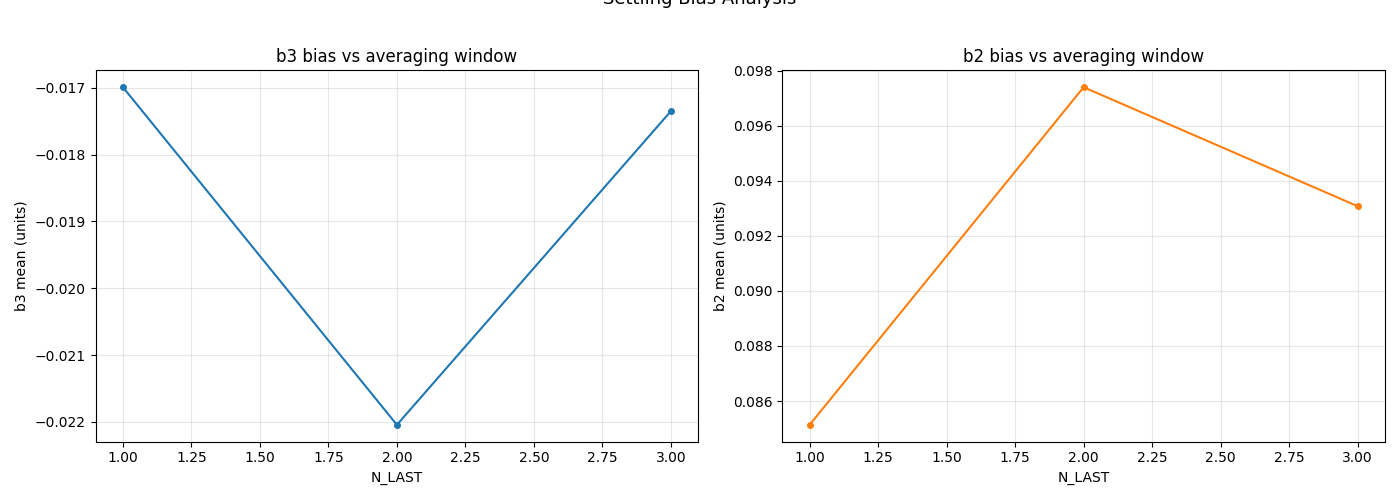

In [24]:
seg = "body"
inj = eddy_data[seg]
if len(inj) > 0 and "turn_in_group" in inj.columns:
    sc_ids = sorted([s for s in inj["sc_idx"].unique() if s >= 0])
    max_turns = inj.groupby("sc_idx").size().min()
    n_last_values = list(range(1, max_turns + 1))

    bias_b3, bias_b2 = [], []
    for n_last in n_last_values:
        b3_m, b2_m = [], []
        for sc_id in sc_ids:
            sub = inj[inj["sc_idx"] == sc_id].sort_values("turn_in_group")
            tail = sub.tail(n_last)
            if len(tail) > 0 and tail["ok_main"].any():
                ok_t = tail[tail["ok_main"]]
                b3_m.append(ok_t["b3_units"].mean())
                b2_m.append(ok_t["b2_units"].mean())
        bias_b3.append(np.mean(b3_m) if b3_m else np.nan)
        bias_b2.append(np.mean(b2_m) if b2_m else np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(n_last_values, bias_b3, "o-", markersize=4, color="tab:blue")
    axes[0].set_xlabel("N_LAST"); axes[0].set_ylabel("b3 mean (units)")
    axes[0].set_title("b3 bias vs averaging window")
    axes[1].plot(n_last_values, bias_b2, "o-", markersize=4, color="tab:orange")
    axes[1].set_xlabel("N_LAST"); axes[1].set_ylabel("b2 mean (units)")
    axes[1].set_title("b2 bias vs averaging window")
    fig.suptitle("Settling Bias Analysis", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("No injection data for bias analysis.")

---
## 22. N_LAST Sensitivity Study

Scan N_LAST and show convergence.

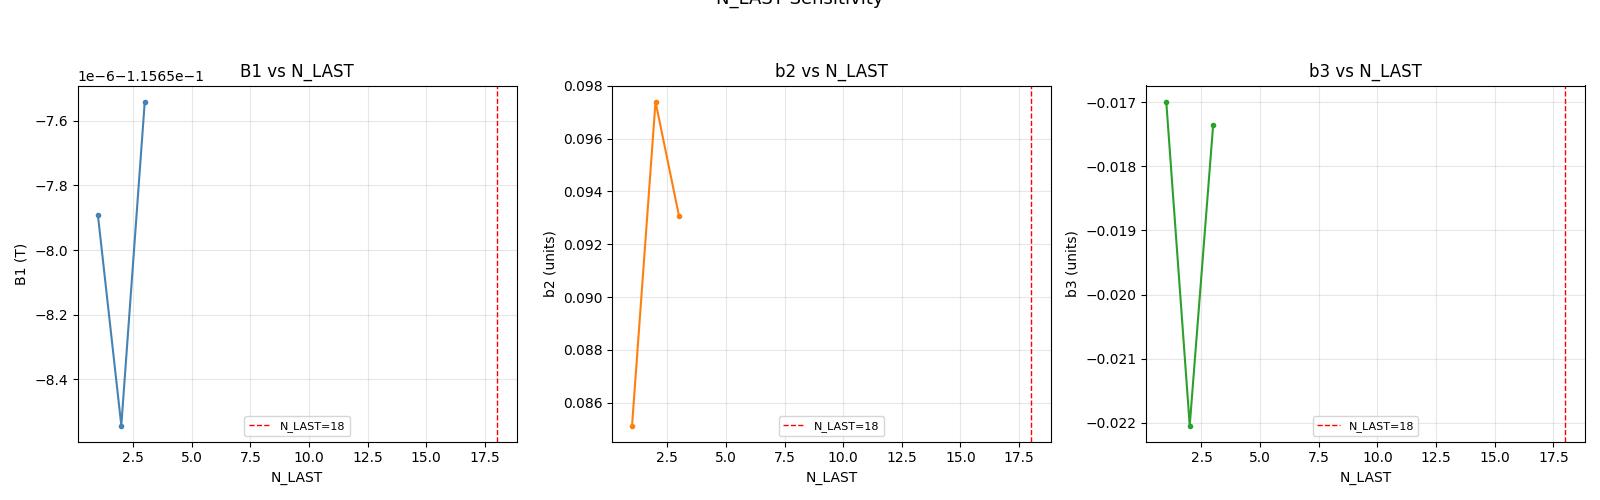

In [25]:
seg = "body"
d = data[seg]
_df = results[seg]["df"]
inj_all = _df[_df["label"] == "injection"].copy()

if len(inj_all) > 0:
    turns_per_sc = inj_all.groupby("sc_idx").size()
    max_n_last = int(turns_per_sc.min())
    n_last_scan = list(range(1, max_n_last + 1))

    scan_results = {"B1_T": [], "b2_units": [], "b3_units": []}
    for n_last in n_last_scan:
        settled_idx = []
        for sc_id in inj_all["sc_idx"].unique():
            if sc_id < 0: continue
            group_rows = inj_all.index[inj_all["sc_idx"] == sc_id]
            if len(group_rows) > n_last:
                settled_idx.extend(group_rows[-n_last:])
            else:
                settled_idx.extend(group_rows)
        sub = inj_all.loc[sorted(settled_idx)]
        sub_ok = sub[sub["ok_main"]]
        for col in ["B1_T", "b2_units", "b3_units"]:
            scan_results[col].append(sub_ok[col].mean() if len(sub_ok) > 0 else np.nan)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (col, ylabel, color) in zip(axes, [
            ("B1_T", "B1 (T)", "steelblue"),
            ("b2_units", "b2 (units)", "tab:orange"),
            ("b3_units", "b3 (units)", "tab:green")]):
        ax.plot(n_last_scan, scan_results[col], "o-", markersize=3, color=color)
        ax.axvline(N_LAST_TURNS_INJ, color="red", linestyle="--", linewidth=1,
                    label=f"N_LAST={N_LAST_TURNS_INJ}")
        ax.set_xlabel("N_LAST"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel.split()[0]} vs N_LAST"); ax.legend(fontsize=8)
    fig.suptitle("N_LAST Sensitivity", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("No injection data for N_LAST sensitivity.")

---
## 23. Comprehensive Statistics Table

In [26]:
print("=" * 70)
print("SPS MBB Dipole -- 26 GeV MD1, ~176 RPM")
print("=" * 70)
print(f"Options: {OPTIONS}")
print(f"cel/fed: {diag.recommendation}")

for seg in SEGMENTS:
    d = data[seg]
    df_settled = results[seg]["df_settled"]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe = " [FRINGE]" if _scfg["is_fringe"] else ""

    print(f"\n--- {seg}{fringe} ---")
    print(f"  Total turns: {d['n_turns']}, Plateau: {d['is_plateau'].sum()}")

    for lab in ["injection", "flat-high"]:
        sub = df_settled[(df_settled["label"] == lab) & df_settled["ok_main"]]
        if len(sub) > 0:
            tf = sub["B1_T"].mean() / (sub["I_mean_A"].mean() / 1e3)
            print(f"  {lab:12s}: N={len(sub):4d}, I={sub['I_mean_A'].mean():.1f} A, "
                  f"B1={sub['B1_T'].mean():+.6f} T, "
                  f"b2={sub['b2_units'].mean():+.3f}, b3={sub['b3_units'].mean():+.3f}, "
                  f"TF={tf:.4f} T/kA")

SPS MBB Dipole -- 26 GeV MD1, ~176 RPM
Options: ('dri', 'rot')
cel/fed: UNSAFE

--- body ---
  Total turns: 2044, Plateau: 1930
  injection   : N= 356, I=300.9 A, B1=-0.115623 T, b2=+0.088, b3=-0.010, TF=-0.3842 T/kA
  flat-high   : N=  19, I=4815.9 A, B1=-1.781262 T, b2=+0.087, b3=+0.020, TF=-0.3699 T/kA

--- fringe [FRINGE] ---
  Total turns: 1981, Plateau: 1866
  injection   : N= 360, I=300.9 A, B1=-0.019564 T, b2=-1.493, b3=+4.887, TF=-0.0650 T/kA
  flat-high   : N=  19, I=4815.9 A, B1=-0.290912 T, b2=+0.754, b3=+7.119, TF=-0.0604 T/kA


---
## 24. Analysis Choices Summary

Document all analysis parameters for reproducibility.

In [27]:
import datetime
print("ANALYSIS CHOICES")
print("=" * 60)
print(f"Generated    : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Title        : SPS MBB Dipole -- 26 GeV MD1, ~176 RPM")
print(f"Segments     : {SEGMENTS}")
print(f"Magnet order : {MAGNET_ORDER}")
print(f"R_ref        : {R_REF} m")
print(f"Samples/turn : {SAMPLES_PER_TURN}")
print(f"OPTIONS      : {OPTIONS}")
print(f"MIN_B1_T     : {MIN_B1_T}")
print(f"N_SIGMA_CLIP : {N_SIGMA_CLIP}")

ANALYSIS CHOICES
Generated    : 2026-03-08 21:59
Title        : SPS MBB Dipole -- 26 GeV MD1, ~176 RPM
Segments     : ['body', 'fringe']
Magnet order : 1
R_ref        : 0.02 m
Samples/turn : 1024
OPTIONS      : ('dri', 'rot')
MIN_B1_T     : 0.0001
N_SIGMA_CLIP : 5.0


---
## 25. CSV Export

In [28]:
out_dir = REPO_ROOT / "output" / "MBB/2026-03-06_max_speed_NMR/26GeV"
out_dir.mkdir(parents=True, exist_ok=True)

for seg in SEGMENTS:
    df_all = results[seg]["df"]
    df_settled = results[seg]["df_settled"]

    fname = f"MBB_{seg}_streaming_plateau.csv"
    df_all.to_csv(out_dir / fname, index=False)
    print(f"Wrote {out_dir / fname}  ({len(df_all)} rows)")

    fname_s = f"MBB_{seg}_streaming_settled.csv"
    df_settled.to_csv(out_dir / fname_s, index=False)
    print(f"Wrote {out_dir / fname_s}  ({len(df_settled)} rows)")

# Export eddy multi-tau fit results (mean-based)
_eddy_rows = []
for seg in SEGMENTS:
    for col, qlabel in EDDY_QUANTITIES:
        res = eddy_fit_all.get(seg, {}).get(col, {})
        bn = res.get("best_ntau")
        bp = res.get("best_popt")
        br = res.get("best_r2", 0)
        if bp is None or br <= 0:
            continue
        row = {"segment": seg, "quantity": col, "model": f"{bn}-tau", "R2": br, "B_inf": bp[0]}
        if bn >= 1:
            row["A1"] = bp[1]; row["tau1_s"] = bp[2]
        if bn >= 2:
            row["A2"] = bp[3]; row["tau2_s"] = bp[4]
        if bn >= 3:
            row["A3"] = bp[5]; row["tau3_s"] = bp[6]
        _eddy_rows.append(row)
if _eddy_rows:
    _df_eddy = pd.DataFrame(_eddy_rows)
    fname_e = "eddy_fits_mean.csv"
    _df_eddy.to_csv(out_dir / fname_e, index=False)
    print(f"Wrote {out_dir / fname_e}  ({len(_df_eddy)} rows)")

    # Export injection raw data for eddy analysis
    inj = eddy_data.get(seg, pd.DataFrame())
    if len(inj) > 0:
        fname_inj = f"eddy_injection_{seg}.csv"
        inj.to_csv(out_dir / fname_inj, index=False)
        print(f"Wrote {out_dir / fname_inj}  ({len(inj)} rows)")

print("\nDone.")

Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-03-06_max_speed_NMR\26GeV\MBB_body_streaming_plateau.csv  (1588 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-03-06_max_speed_NMR\26GeV\MBB_body_streaming_settled.csv  (375 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-03-06_max_speed_NMR\26GeV\MBB_fringe_streaming_plateau.csv  (1588 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-03-06_max_speed_NMR\26GeV\MBB_fringe_streaming_settled.csv  (379 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-03-06_max_speed_NMR\26GeV\eddy_fits_mean.csv  (6 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MBB\2026-03-06_max_speed_NMR\26GeV\eddy_injection_fringe.csv  (1562 rows)

Done.
